# Week 11: Unsupervised Learning — Clustering and Dimensionality Reduction
## Course: Digital Health and AI in Medical Applications (BME 7451)
### Instructor: Prof. Che-Wei Lin, NCKU BME

---

**Learning Objectives:**
1. Explain when and why unsupervised learning is needed in clinical data analysis (Understand)
2. Implement K-Means, DBSCAN, hierarchical clustering, and GMM on patient data (Apply)
3. Evaluate clustering quality using silhouette score, elbow method, and clinical validation (Analyze)
4. Apply PCA, t-SNE, and UMAP to visualize high-dimensional clinical data (Apply)
5. Connect clustering results to clinical phenotyping and treatment stratification (Evaluate)

**Tools:** Google Colab + Gemini AI
**Libraries:** scikit-learn, umap-learn, scipy, matplotlib, seaborn
**Dataset:** Breast Cancer Wisconsin (sklearn) + synthetic fallback
**Estimated Time:** 45-55 minutes

---

### Red Thread: The Diabetes Subtyping Mystery

> A 58-year-old woman with Type 2 diabetes has been on metformin for two years —
> her HbA1c has not budged. Meanwhile, a 61-year-old man with nearly identical lab
> values responds beautifully to the same drug. Same diagnosis, same treatment,
> opposite outcomes. What if "Type 2 diabetes" is not one disease — but THREE or
> FOUR distinct diseases lumped under one label?
>
> **Ahlqvist et al. (Lancet, 2018):** Clustered 8,980 diabetic patients using
> just 6 clinical variables and discovered **5 distinct subtypes**, each with
> different progression rates and complication risks. Subtype 3 (severe
> insulin-resistant) had the highest kidney disease risk — but standard guidelines
> never identified it.
>
> Today, every algorithm and visualization technique connects back to this mystery:
> **Can unsupervised learning discover hidden subtypes that explain why identical
> treatments produce opposite outcomes?**


## 0. Environment Setup

Install required packages and import libraries. We use:
- **scikit-learn** for clustering algorithms and evaluation metrics
- **umap-learn** for UMAP dimensionality reduction
- **scipy** for hierarchical clustering dendrograms
- **matplotlib / seaborn** for visualization


In [66]:
# ============================================================
# Section 0: Environment Setup
# ============================================================
!pip install umap-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# Scikit-learn imports
from sklearn.datasets import load_breast_cancer, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

# UMAP
import umap

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print("All libraries imported successfully!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")
print(f"UMAP: {umap.__version__}")


All libraries imported successfully!
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn: 1.6.1
UMAP: 0.5.12


## 1. Load and Explore Patient Data

We use the **Breast Cancer Wisconsin** dataset from scikit-learn:
- **569 patients**, each with **30 features** (tumor measurements)
- 2 classes: malignant (212) and benign (357)
- Features include: mean radius, mean texture, mean perimeter, mean area,
  mean smoothness, and more — all computed from digitized images of
  fine needle aspirates (FNA) of breast masses

**Clinical Context:** Imagine these are the lab values and measurements of
hundreds of patients. In unsupervised learning, we **hide** the diagnosis
labels and ask: can the algorithm discover meaningful patient groups on its
own? This mirrors real clinical scenarios where labels do not exist — like
discovering new diabetes subtypes from patient records.

We also create a Pima Diabetes-inspired synthetic dataset to connect
directly to our red thread (diabetes subtyping).


In [67]:
# ============================================================
# Section 1: Load and Explore Patient Data
# ============================================================

# --- Primary dataset: Breast Cancer Wisconsin ---
try:
    cancer = load_breast_cancer()
    X_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
    y_cancer = cancer.target  # 0=malignant, 1=benign (we will hide this)
    print("Breast Cancer Wisconsin dataset loaded successfully!")
    print(f"  Samples: {X_cancer.shape[0]}, Features: {X_cancer.shape[1]}")
    print(f"  Classes: malignant={sum(y_cancer==0)}, benign={sum(y_cancer==1)}")
except Exception as e:
    print(f"Could not load Breast Cancer dataset: {e}")
    print("Using synthetic fallback data...")
    X_blob, y_blob = make_blobs(n_samples=569, n_features=30, centers=2,
                                 cluster_std=3.0, random_state=SEED)
    X_cancer = pd.DataFrame(X_blob, columns=[f"feature_{i}" for i in range(30)])
    y_cancer = y_blob

print()
print("First 5 patients (first 6 features):")
print(X_cancer.iloc[:5, :6].to_string())


Breast Cancer Wisconsin dataset loaded successfully!
  Samples: 569, Features: 30
  Classes: malignant=212, benign=357

First 5 patients (first 6 features):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  mean compactness
0        17.99         10.38          122.80     1001.0          0.11840           0.27760
1        20.57         17.77          132.90     1326.0          0.08474           0.07864
2        19.69         21.25          130.00     1203.0          0.10960           0.15990
3        11.42         20.38           77.58      386.1          0.14250           0.28390
4        20.29         14.34          135.10     1297.0          0.10030           0.13280


In [68]:
# --- Statistical summary of key features ---
key_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean compactness']

# Select features that exist in our dataframe
available = [f for f in key_features if f in X_cancer.columns]
if available:
    print("Statistical Summary of Key Tumor Features:")
    print("=" * 60)
    print(X_cancer[available].describe().round(2).to_string())
else:
    print("Statistical Summary (first 6 features):")
    print("=" * 60)
    print(X_cancer.iloc[:, :6].describe().round(2).to_string())


Statistical Summary of Key Tumor Features:
       mean radius  mean texture  mean perimeter  mean area  mean smoothness  mean compactness
count       569.00        569.00          569.00     569.00           569.00            569.00
mean         14.13         19.29           91.97     654.89             0.10              0.10
std           3.52          4.30           24.30     351.91             0.01              0.05
min           6.98          9.71           43.79     143.50             0.05              0.02
25%          11.70         16.17           75.17     420.30             0.09              0.06
50%          13.37         18.84           86.24     551.10             0.10              0.09
75%          15.78         21.80          104.10     782.70             0.11              0.13
max          28.11         39.28          188.50    2501.00             0.16              0.35


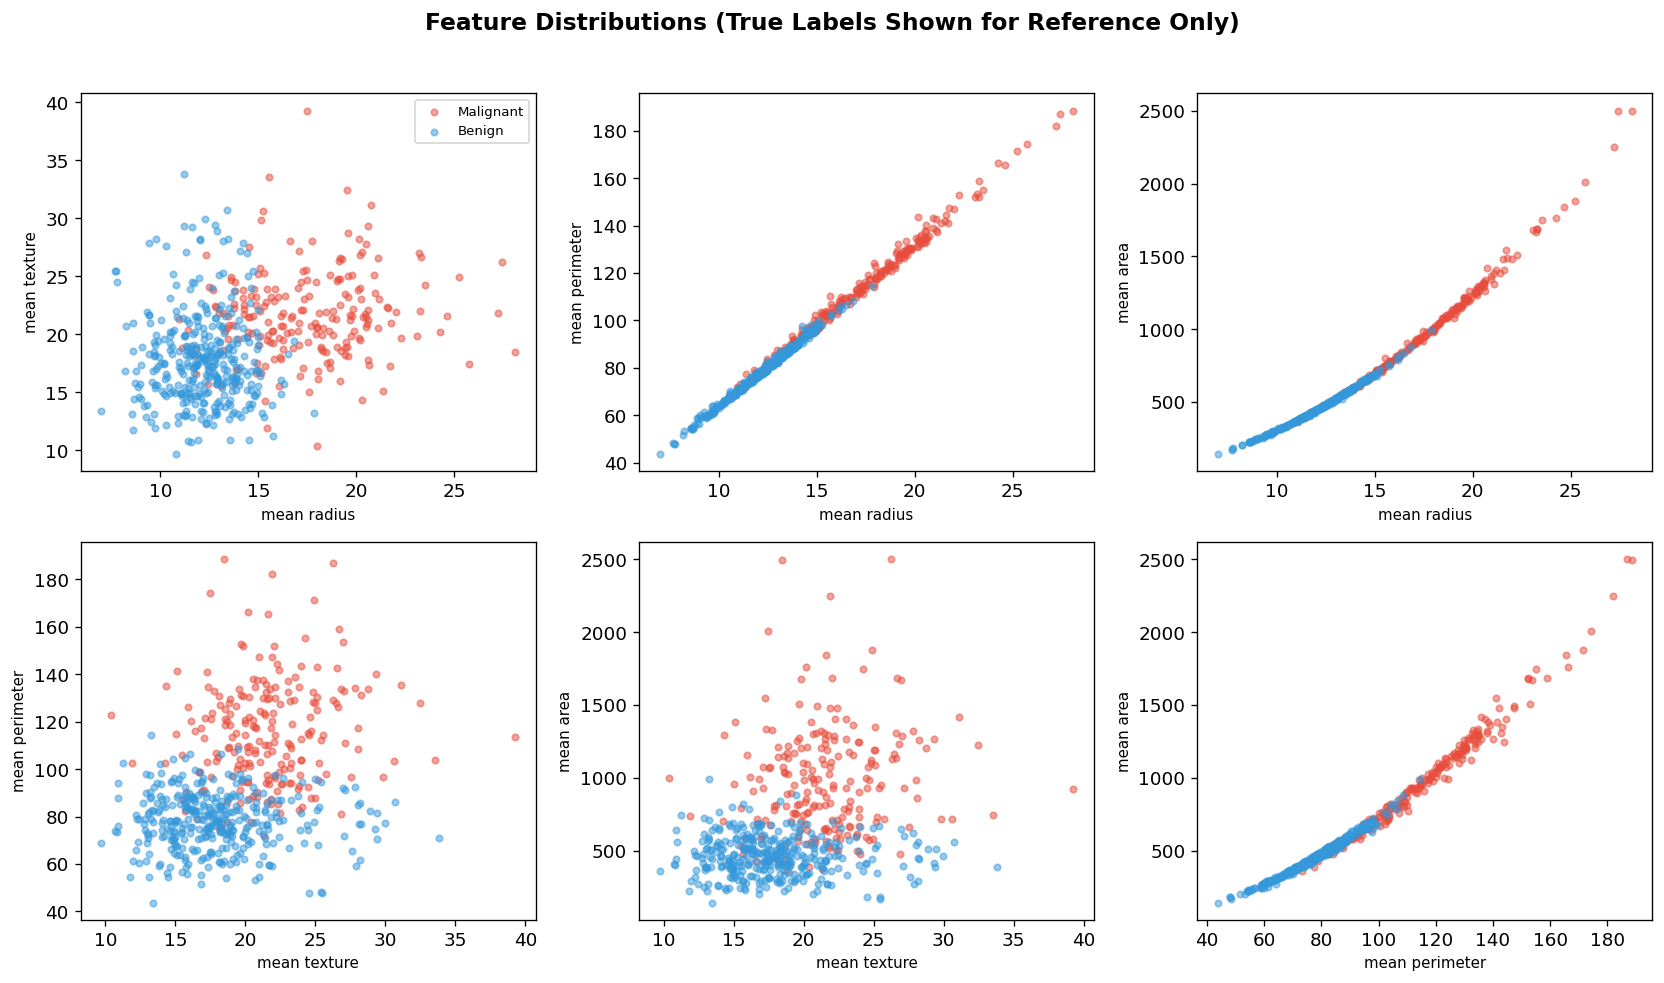

Notice: Some features naturally separate the two groups.
The question: can clustering discover this WITHOUT labels?


In [69]:
# --- Pairplot of selected features (colored by TRUE label for reference) ---
# In real unsupervised learning, we would NOT have these labels!
plot_df = X_cancer.iloc[:, :4].copy()
plot_df['True Label'] = ['Malignant' if y == 0 else 'Benign' for y in y_cancer]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Feature Distributions (True Labels Shown for Reference Only)",
             fontsize=14, fontweight='bold', y=1.02)

feature_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
colors = {0: '#E74C3C', 1: '#3498DB'}

for idx, (i, j) in enumerate(feature_pairs):
    ax = axes[idx // 3, idx % 3]
    for label, color in colors.items():
        mask = y_cancer == label
        ax.scatter(X_cancer.iloc[mask, i], X_cancer.iloc[mask, j],
                   c=color, alpha=0.5, s=15,
                   label='Malignant' if label == 0 else 'Benign')
    ax.set_xlabel(X_cancer.columns[i], fontsize=9)
    ax.set_ylabel(X_cancer.columns[j], fontsize=9)
    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print("Notice: Some features naturally separate the two groups.")
print("The question: can clustering discover this WITHOUT labels?")


## 2. Feature Scaling

**Why scaling is critical for clustering:**

Clustering algorithms rely on **distance calculations** between data points.
If features have very different scales (e.g., mean area ranges from 143 to
2501, while mean smoothness ranges from 0.05 to 0.16), the large-scale
features will dominate the distance calculations and the small-scale
features will be effectively ignored.

**StandardScaler** transforms each feature to have mean=0 and std=1,
ensuring all features contribute equally to the clustering.

> **Clinical analogy:** Scaling is like converting all lab values to their
> Z-scores — so that a hemoglobin value of 14 g/dL and a white blood cell
> count of 8,000/uL can be compared on equal footing.


In [70]:
# ============================================================
# Section 2: Feature Scaling
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cancer)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_cancer.columns)

print("Before scaling (first 3 features):")
print(f"  mean radius  -> mean: {X_cancer.iloc[:, 0].mean():.2f}, std: {X_cancer.iloc[:, 0].std():.2f}")
print(f"  mean texture -> mean: {X_cancer.iloc[:, 1].mean():.2f}, std: {X_cancer.iloc[:, 1].std():.2f}")
print(f"  mean area    -> mean: {X_cancer.iloc[:, 3].mean():.2f}, std: {X_cancer.iloc[:, 3].std():.2f}")

print()
print("After scaling (first 3 features):")
print(f"  mean radius  -> mean: {X_scaled_df.iloc[:, 0].mean():.4f}, std: {X_scaled_df.iloc[:, 0].std():.4f}")
print(f"  mean texture -> mean: {X_scaled_df.iloc[:, 1].mean():.4f}, std: {X_scaled_df.iloc[:, 1].std():.4f}")
print(f"  mean area    -> mean: {X_scaled_df.iloc[:, 3].mean():.4f}, std: {X_scaled_df.iloc[:, 3].std():.4f}")


Before scaling (first 3 features):
  mean radius  -> mean: 14.13, std: 3.52
  mean texture -> mean: 19.29, std: 4.30
  mean area    -> mean: 654.89, std: 351.91

After scaling (first 3 features):
  mean radius  -> mean: -0.0000, std: 1.0009
  mean texture -> mean: -0.0000, std: 1.0009
  mean area    -> mean: -0.0000, std: 1.0009


/tmp/ipykernel_2338/771766148.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X_cancer.iloc[:, i] for i in range(6)],
/tmp/ipykernel_2338/771766148.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_scaled_df.iloc[:, i] for i in range(6)],


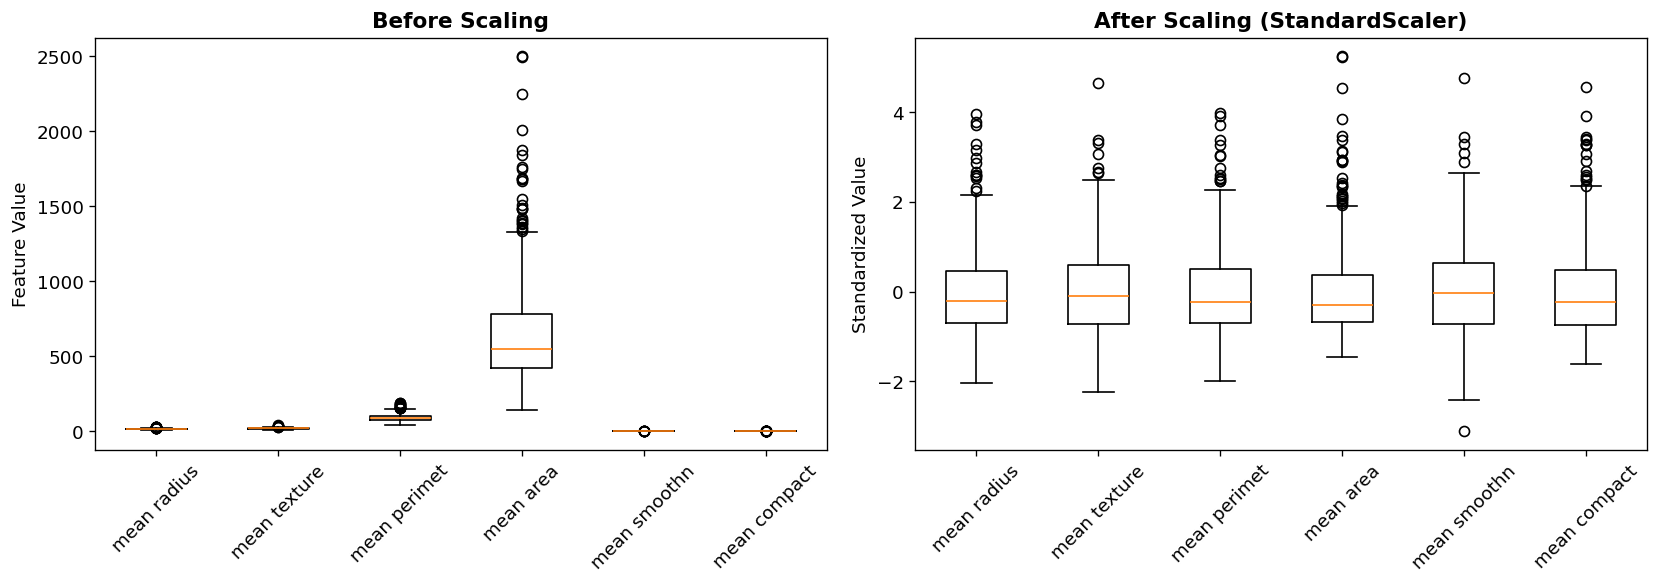

After scaling, all features have comparable ranges.
This ensures no single feature dominates the distance calculations.


In [71]:
# --- Visualize the effect of scaling ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].boxplot([X_cancer.iloc[:, i] for i in range(6)],
                labels=[c[:12] for c in X_cancer.columns[:6]])
axes[0].set_title("Before Scaling", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Feature Value")
axes[0].tick_params(axis='x', rotation=45)

# After scaling
axes[1].boxplot([X_scaled_df.iloc[:, i] for i in range(6)],
                labels=[c[:12] for c in X_cancer.columns[:6]])
axes[1].set_title("After Scaling (StandardScaler)", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Standardized Value")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("After scaling, all features have comparable ranges.")
print("This ensures no single feature dominates the distance calculations.")


## 3. K-Means Clustering

**K-Means** is the workhorse clustering algorithm:
1. Pick K random centroids
2. Assign each patient to the nearest centroid
3. Recompute centroids as the mean of assigned patients
4. Repeat until stable (convergence)

**Key question:** How do we choose K? Two methods:
- **Elbow Method:** Plot inertia (within-cluster sum of squares) vs K.
  The "elbow" indicates the optimal K — beyond that point, adding more
  clusters provides diminishing returns.
- **Silhouette Score:** Measures how similar each point is to its own
  cluster vs other clusters. Range: -1 (wrong cluster) to +1 (well-matched).

> **Clinical connection:** The Ahlqvist diabetes study used hierarchical
> clustering — but if they had used K-Means, the elbow at K=5 would have
> suggested the same five subtypes. The algorithm does not know about
> diabetes — it simply finds natural groups in the data.


In [72]:
# ============================================================
# Section 3: K-Means Clustering — Elbow Plot and Silhouette Scores
# ============================================================

# Try K = 2 through 8
K_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: Inertia={km.inertia_:.1f}, Silhouette={sil:.4f}")

print()
print("Look for the 'elbow' in inertia and the peak in silhouette score.")


K=2: Inertia=11595.5, Silhouette=0.3434
K=3: Inertia=10061.8, Silhouette=0.3144
K=4: Inertia=9259.0, Silhouette=0.2833
K=5: Inertia=8558.7, Silhouette=0.1582
K=6: Inertia=7970.3, Silhouette=0.1604
K=7: Inertia=7540.3, Silhouette=0.1532
K=8: Inertia=7254.3, Silhouette=0.1472

Look for the 'elbow' in inertia and the peak in silhouette score.


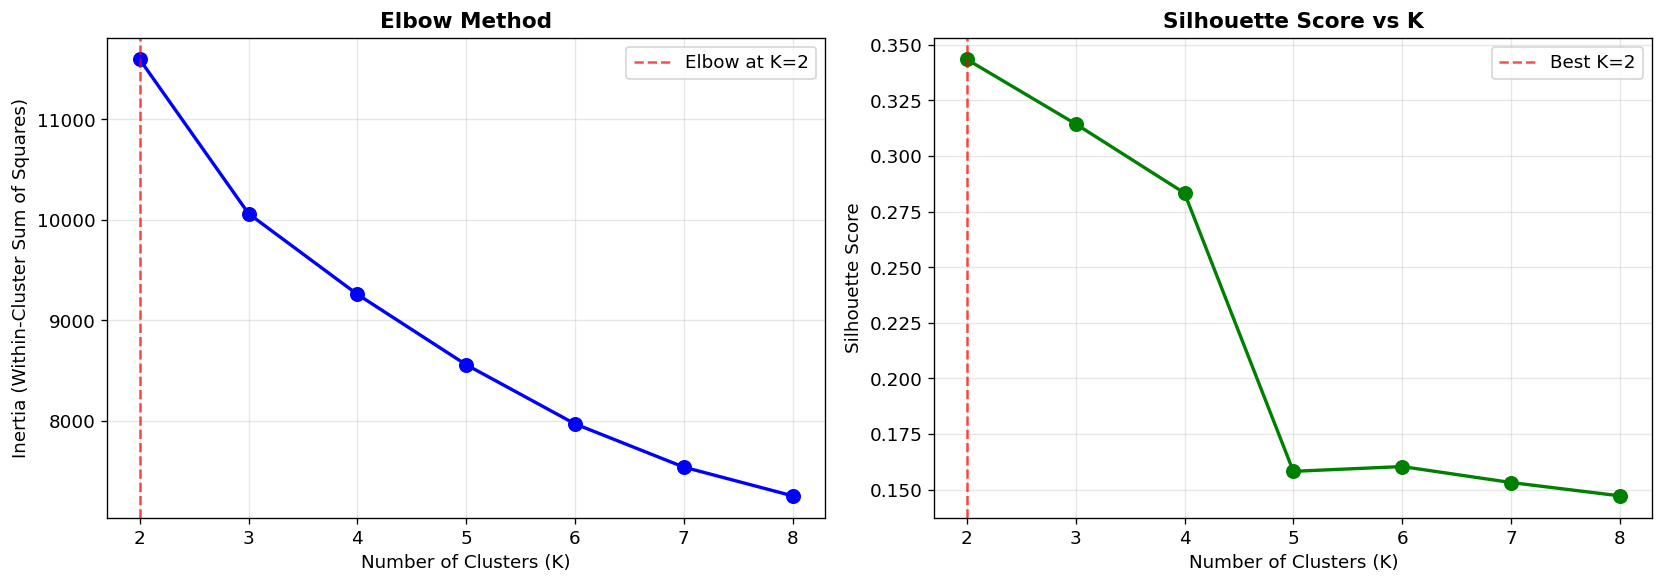

Best silhouette score: 0.3434 at K=2
For breast cancer data, K=2 makes biological sense (malignant vs benign).
For diabetes subtyping, Ahlqvist found the elbow at K=5.


In [73]:
# --- Elbow plot and silhouette score plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)")
axes[0].set_title("Elbow Method", fontsize=13, fontweight='bold')
axes[0].axvline(x=2, color='red', linestyle='--', alpha=0.7, label='Elbow at K=2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette score plot
axes[1].plot(list(K_range), silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs K", fontsize=13, fontweight='bold')
best_k_sil = list(K_range)[np.argmax(silhouette_scores)]
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', alpha=0.7,
                label=f'Best K={best_k_sil}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best silhouette score: {max(silhouette_scores):.4f} at K={best_k_sil}")
print("For breast cancer data, K=2 makes biological sense (malignant vs benign).")
print("For diabetes subtyping, Ahlqvist found the elbow at K=5.")


In [74]:
# --- Fit K-Means with optimal K and examine clusters ---
optimal_k = 2  # For breast cancer data, 2 is most meaningful
km_final = KMeans(n_clusters=optimal_k, random_state=SEED, n_init=10)
km_labels = km_final.fit_predict(X_scaled)

print(f"K-Means clustering with K={optimal_k}:")
print(f"  Cluster sizes: {np.bincount(km_labels)}")
print(f"  Silhouette score: {silhouette_score(X_scaled, km_labels):.4f}")

# Compare with true labels (for educational purposes)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(y_cancer, km_labels)
nmi = normalized_mutual_info_score(y_cancer, km_labels)
print(f"  Adjusted Rand Index (vs true labels): {ari:.4f}")
print(f"  Normalized Mutual Information: {nmi:.4f}")
print()
print("Note: In real unsupervised learning, we would NOT have true labels")
print("to compute ARI/NMI. This comparison is for educational validation only.")


K-Means clustering with K=2:
  Cluster sizes: [375 194]
  Silhouette score: 0.3434
  Adjusted Rand Index (vs true labels): 0.6536
  Normalized Mutual Information: 0.5324

Note: In real unsupervised learning, we would NOT have true labels
to compute ARI/NMI. This comparison is for educational validation only.


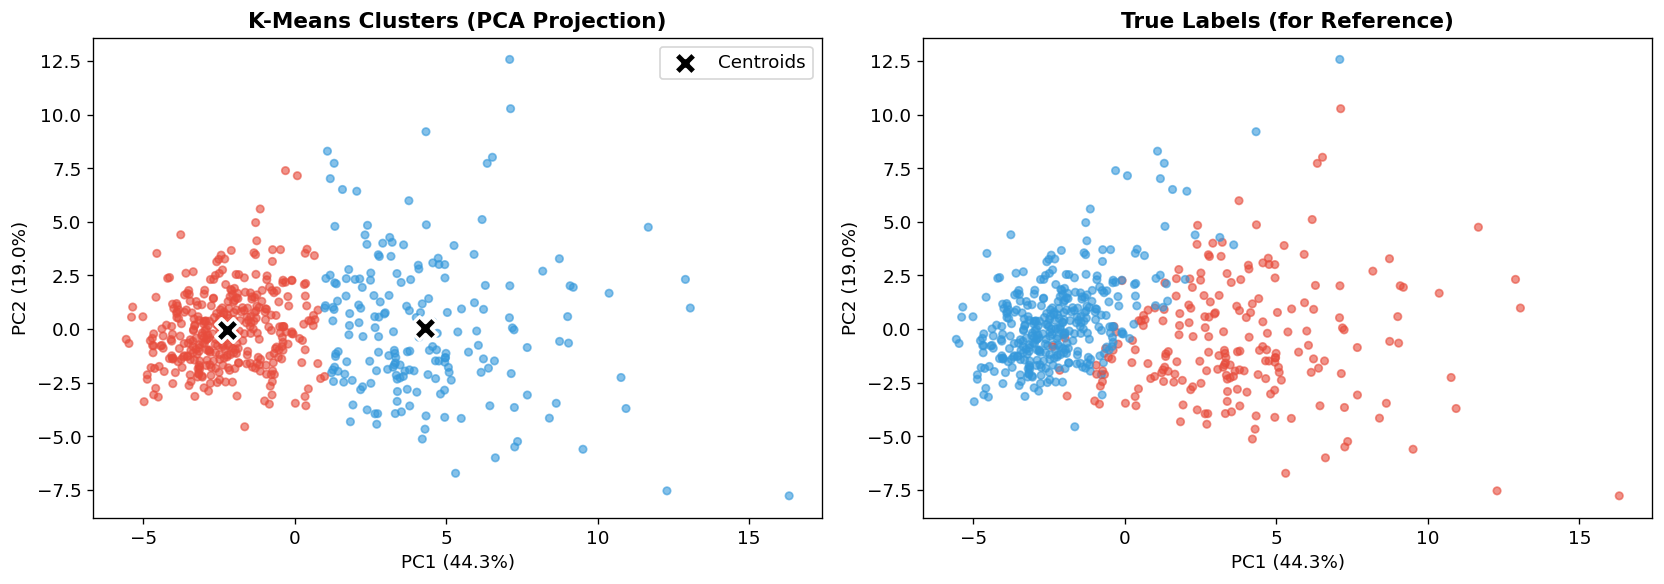

PCA: PC1 + PC2 explain 63.2% of total variance.
Compare left (K-Means) vs right (True Labels) — how well did K-Means do?


In [75]:
# --- Visualize K-Means clusters using PCA for 2D projection ---
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means clusters
colors_km = ['#E74C3C' if l == 0 else '#3498DB' for l in km_labels]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_km, alpha=0.6, s=20)
# Plot centroids projected into PCA space
centroids_pca = pca_2d.transform(km_final.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=200, edgecolors='white', linewidths=2,
                label='Centroids')
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("K-Means Clusters (PCA Projection)", fontsize=13, fontweight='bold')
axes[0].legend()

# True labels for comparison
colors_true = ['#E74C3C' if l == 0 else '#3498DB' for l in y_cancer]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_true, alpha=0.6, s=20)
axes[1].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("True Labels (for Reference)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

var_explained = sum(pca_2d.explained_variance_ratio_) * 100
print(f"PCA: PC1 + PC2 explain {var_explained:.1f}% of total variance.")
print("Compare left (K-Means) vs right (True Labels) — how well did K-Means do?")


## 4. Hierarchical Clustering

**Hierarchical (Agglomerative) Clustering** builds a tree of clusters:
1. Start with each patient as its own cluster
2. Merge the two most similar clusters
3. Repeat until all patients are in one cluster
4. Cut the tree (dendrogram) at different heights to get different numbers of clusters

**Linkage methods** determine how to measure distance between clusters:
- **Ward's:** Minimize within-cluster variance (most compact clusters)
- **Complete:** Use maximum distance between any two points
- **Average:** Use mean distance between all pairs
- **Single:** Use minimum distance (can create "chain" clusters)

> **Clinical analogy:** A dendrogram is like a taxonomy of disease.
> At the top: "all patients." Cut lower: "malignant vs benign."
> Cut even lower: specific subtypes emerge. The tree reveals
> relationships between subtypes — which ones are most similar.


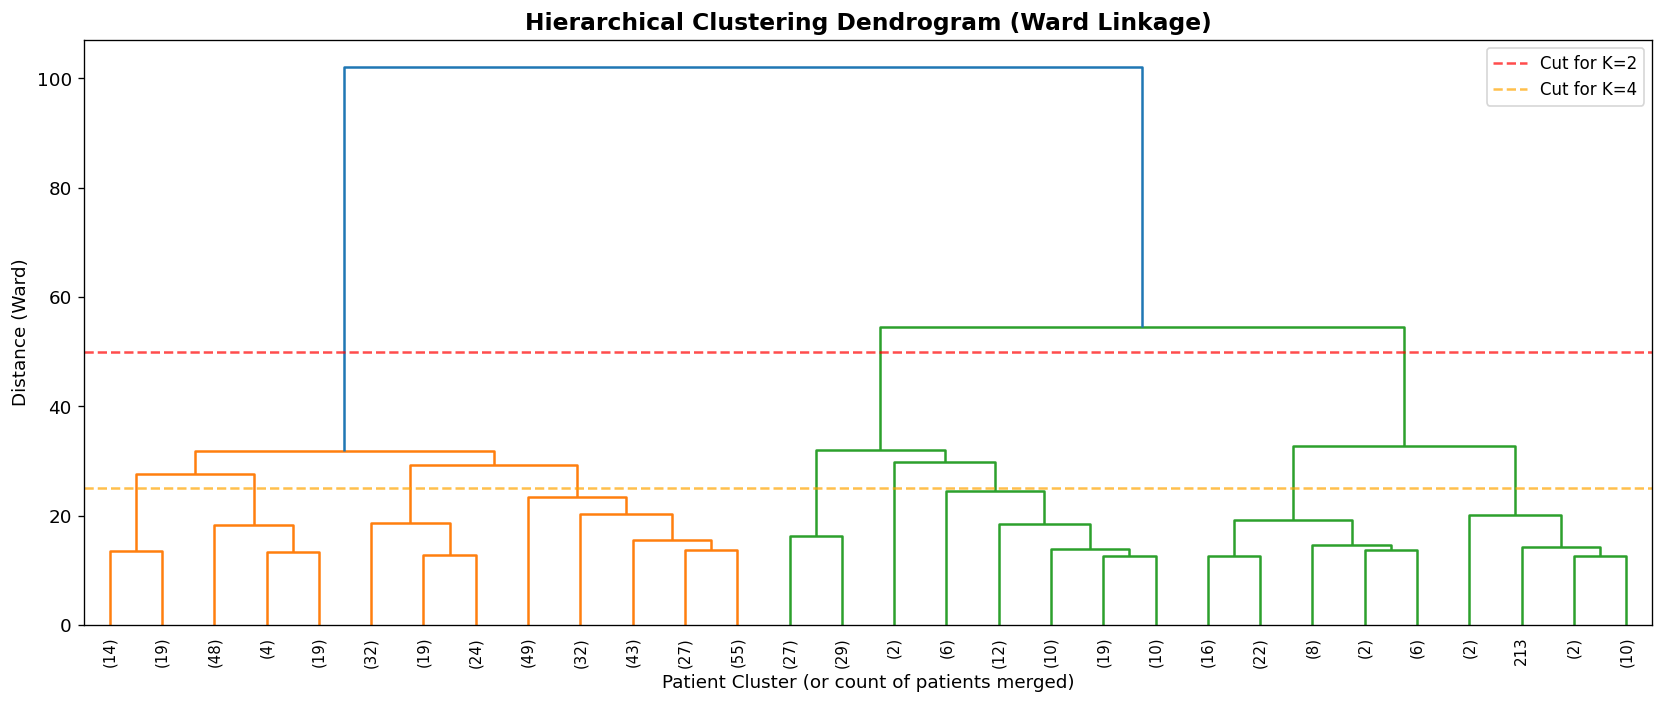

The dendrogram reveals hierarchical structure in the data.
Cutting at height ~50 gives 2 major groups (similar to malignant/benign).
Cutting lower reveals sub-clusters within each major group.


In [76]:
# ============================================================
# Section 4: Hierarchical Clustering — Dendrogram
# ============================================================

# Compute linkage matrix using Ward's method
Z = linkage(X_scaled, method='ward', metric='euclidean')

# Plot dendrogram
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
dn = dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
                leaf_font_size=9, ax=ax,
                color_threshold=0.7 * max(Z[:, 2]))
ax.set_title("Hierarchical Clustering Dendrogram (Ward Linkage)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Patient Cluster (or count of patients merged)")
ax.set_ylabel("Distance (Ward)")
ax.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='Cut for K=2')
ax.axhline(y=25, color='orange', linestyle='--', alpha=0.7, label='Cut for K=4')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("The dendrogram reveals hierarchical structure in the data.")
print("Cutting at height ~50 gives 2 major groups (similar to malignant/benign).")
print("Cutting lower reveals sub-clusters within each major group.")


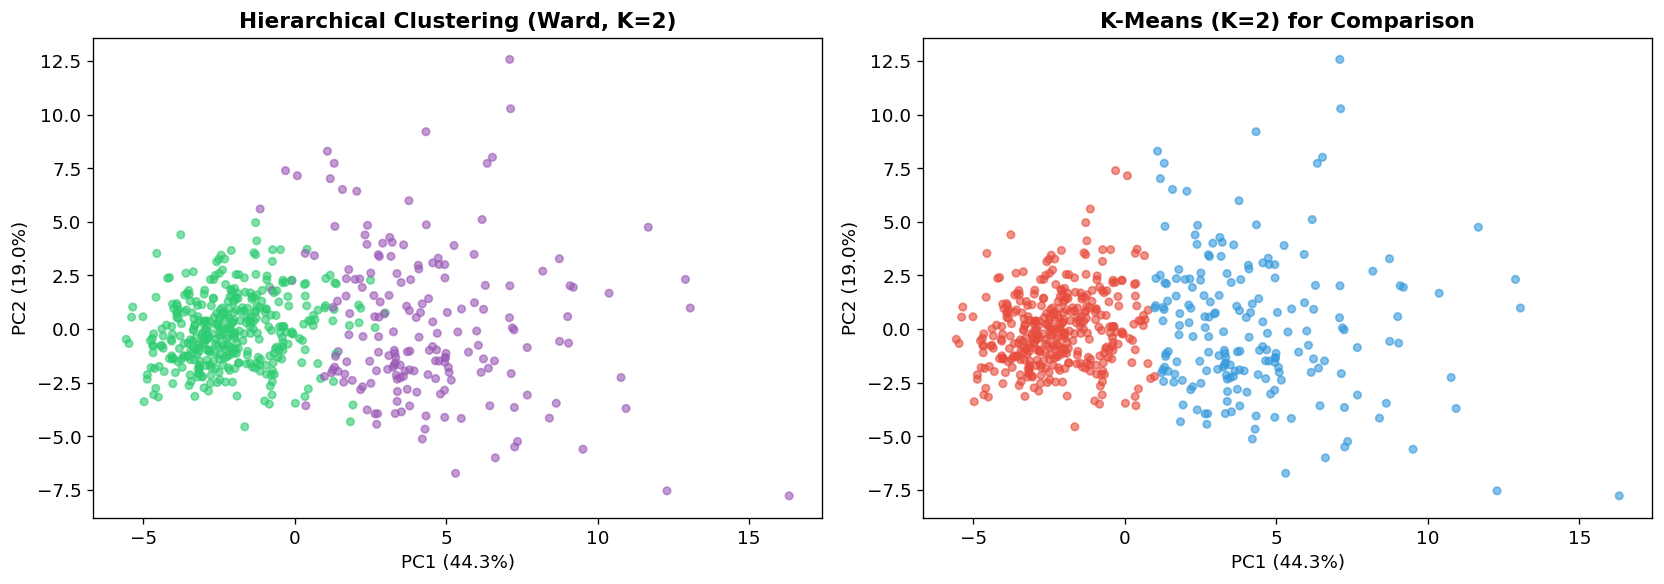

Hierarchical Clustering: Silhouette=0.3394, ARI=0.5750
K-Means:                 Silhouette=0.3434, ARI=0.6536

Both methods find similar structure — but hierarchical clustering
also gives us the dendrogram showing relationships BETWEEN clusters.


In [77]:
# --- Agglomerative Clustering with K=2 and compare ---
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

# Visualize on PCA space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_agg = ['#9B59B6' if l == 0 else '#2ECC71' for l in agg_labels]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_agg, alpha=0.6, s=20)
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("Hierarchical Clustering (Ward, K=2)", fontsize=13, fontweight='bold')

colors_km2 = ['#E74C3C' if l == 0 else '#3498DB' for l in km_labels]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_km2, alpha=0.6, s=20)
axes[1].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("K-Means (K=2) for Comparison", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

sil_agg = silhouette_score(X_scaled, agg_labels)
ari_agg = adjusted_rand_score(y_cancer, agg_labels)
print(f"Hierarchical Clustering: Silhouette={sil_agg:.4f}, ARI={ari_agg:.4f}")
print(f"K-Means:                 Silhouette={silhouette_score(X_scaled, km_labels):.4f}, ARI={adjusted_rand_score(y_cancer, km_labels):.4f}")
print()
print("Both methods find similar structure — but hierarchical clustering")
print("also gives us the dendrogram showing relationships BETWEEN clusters.")


## 5. DBSCAN Clustering

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise)
finds clusters based on **density**, not distance to centroids:
- **Core points:** Have at least `min_samples` neighbors within `eps` radius
- **Border points:** Within `eps` of a core point but not core themselves
- **Noise points:** Not near any core point — labeled as `-1`

**Key advantages over K-Means:**
- Does NOT require specifying K in advance
- Finds clusters of **arbitrary shape** (not just spheres)
- Identifies **outliers** automatically

> **Clinical analogy:** K-Means forces every patient into a group.
> DBSCAN says "these 12 patients do not fit anywhere" — clinically,
> those outliers might be rare subtypes or data errors worth investigating.

**Challenge:** Choosing `eps` (neighborhood radius). Too small = everything
is noise. Too large = everything is one cluster. We use PCA-reduced data
for more effective density-based clustering in high dimensions.


In [78]:
# ============================================================
# Section 5: DBSCAN Clustering
# ============================================================

# DBSCAN works better on lower-dimensional data, so we use PCA first
pca_10 = PCA(n_components=10, random_state=SEED)
X_pca10 = pca_10.fit_transform(X_scaled)
print(f"PCA reduced 30 features to 10 components")
print(f"Variance explained: {sum(pca_10.explained_variance_ratio_)*100:.1f}%")

# --- Try different epsilon values ---
eps_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
print()
print("Exploring epsilon values for DBSCAN:")
print("-" * 60)

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    db_labels = db.fit_predict(X_pca10)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = sum(db_labels == -1)
    if n_clusters >= 2:
        sil = silhouette_score(X_pca10[db_labels != -1],
                               db_labels[db_labels != -1])
        print(f"  eps={eps:.1f}: {n_clusters} clusters, {n_noise} noise points, silhouette={sil:.4f}")
    else:
        print(f"  eps={eps:.1f}: {n_clusters} cluster(s), {n_noise} noise points (cannot compute silhouette)")


PCA reduced 30 features to 10 components
Variance explained: 95.2%

Exploring epsilon values for DBSCAN:
------------------------------------------------------------
  eps=1.5: 2 clusters, 479 noise points, silhouette=0.1053
  eps=2.0: 7 clusters, 272 noise points, silhouette=0.1422
  eps=2.5: 1 cluster(s), 146 noise points (cannot compute silhouette)
  eps=3.0: 1 cluster(s), 83 noise points (cannot compute silhouette)
  eps=3.5: 1 cluster(s), 51 noise points (cannot compute silhouette)
  eps=4.0: 1 cluster(s), 33 noise points (cannot compute silhouette)


DBSCAN (eps=2.5, min_samples=5):
  Clusters found: 1
  Noise points: 146 (25.7%)
  Noise: 146 patients
  Cluster 0: 423 patients


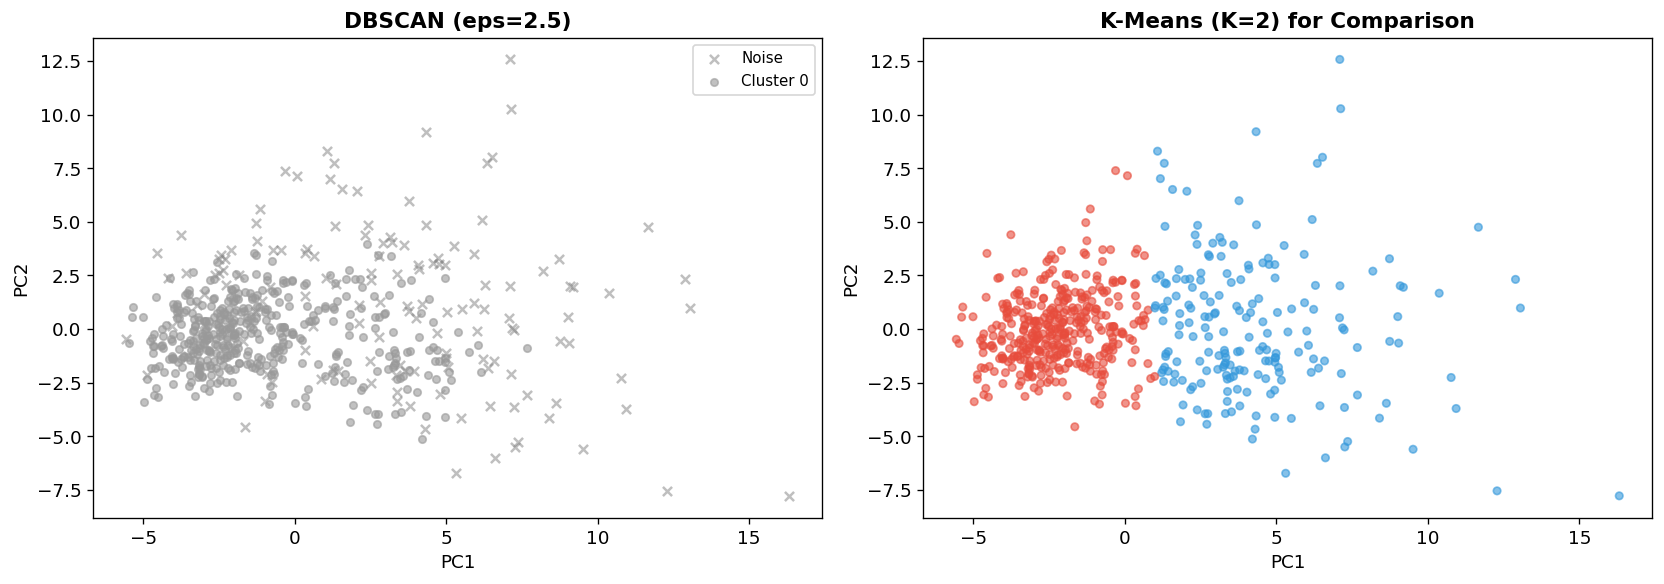


DBSCAN identifies outlier patients that do not fit any cluster.
In clinical practice, these outliers might be rare subtypes or data errors.
K-Means forces EVERY patient into a cluster — even if they do not belong.


In [79]:
# --- Fit DBSCAN with a good epsilon and visualize ---
chosen_eps = 2.5
db_final = DBSCAN(eps=chosen_eps, min_samples=5)
db_labels = db_final.fit_predict(X_pca10)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = sum(db_labels == -1)

print(f"DBSCAN (eps={chosen_eps}, min_samples=5):")
print(f"  Clusters found: {n_clusters_db}")
print(f"  Noise points: {n_noise_db} ({n_noise_db/len(db_labels)*100:.1f}%)")
for label in sorted(set(db_labels)):
    count = sum(db_labels == label)
    name = "Noise" if label == -1 else f"Cluster {label}"
    print(f"  {name}: {count} patients")

# Visualize on PCA 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DBSCAN clusters
unique_labels = sorted(set(db_labels))
cmap_colors = plt.cm.Set1(np.linspace(0, 1, max(len(unique_labels), 2)))
for idx, label in enumerate(unique_labels):
    mask = db_labels == label
    if label == -1:
        axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c='gray', marker='x', s=30, alpha=0.5, label='Noise')
    else:
        axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=[cmap_colors[idx]], alpha=0.6, s=20,
                       label=f'Cluster {label}')
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title(f"DBSCAN (eps={chosen_eps})", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

# K-Means for comparison
colors_km3 = ['#E74C3C' if l == 0 else '#3498DB' for l in km_labels]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_km3, alpha=0.6, s=20)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("K-Means (K=2) for Comparison", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print()
print("DBSCAN identifies outlier patients that do not fit any cluster.")
print("In clinical practice, these outliers might be rare subtypes or data errors.")
print("K-Means forces EVERY patient into a cluster — even if they do not belong.")


## 6. Gaussian Mixture Models (GMM) — Soft Clustering

**GMM** assumes data is generated from a mixture of Gaussian distributions.
Unlike K-Means (hard assignment: each patient belongs to exactly one cluster),
GMM provides **soft assignment** — each patient has a **probability** of
belonging to each cluster.

> **Clinical insight:** A patient with borderline features does not neatly
> fit one subtype. GMM says: "This patient is 65% insulin-resistant subtype,
> 35% obesity-related subtype." This is clinically honest about uncertainty
> — much more useful than forcing a binary classification.

**Comparison:**
| Feature | K-Means | GMM |
|---------|---------|-----|
| Assignment | Hard (0 or 1) | Soft (probabilities) |
| Shape | Spherical clusters | Elliptical clusters |
| Selection | Elbow / Silhouette | BIC / AIC |


GMM n_components=2: BIC=6094.0, AIC=1789.3
GMM n_components=3: BIC=6252.0, AIC=-207.3
GMM n_components=4: BIC=6364.5, AIC=-2249.4
GMM n_components=5: BIC=7859.3, AIC=-2909.1
GMM n_components=6: BIC=7206.6, AIC=-5716.4


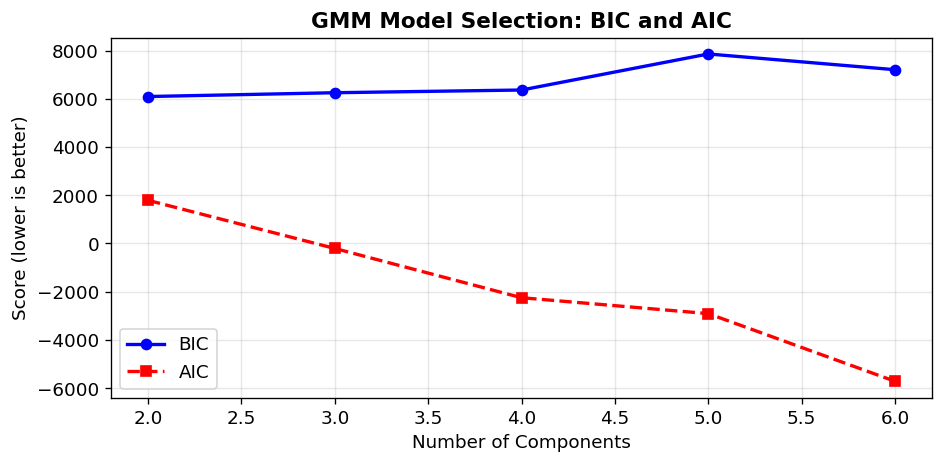

Best number of components by BIC: 2


In [80]:
# ============================================================
# Section 6: Gaussian Mixture Models (GMM)
# ============================================================

# Fit GMM with different numbers of components
n_components_range = range(2, 7)
bic_scores = []
aic_scores = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=SEED,
                          covariance_type='full', n_init=3)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    print(f"GMM n_components={n}: BIC={gmm.bic(X_scaled):.1f}, AIC={gmm.aic(X_scaled):.1f}")

# Plot BIC and AIC
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(n_components_range), bic_scores, 'bo-', label='BIC', linewidth=2)
ax.plot(list(n_components_range), aic_scores, 'rs--', label='AIC', linewidth=2)
ax.set_xlabel("Number of Components")
ax.set_ylabel("Score (lower is better)")
ax.set_title("GMM Model Selection: BIC and AIC", fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_n_bic = list(n_components_range)[np.argmin(bic_scores)]
print(f"Best number of components by BIC: {best_n_bic}")


In [81]:
# --- Fit GMM with K=2 and examine soft assignments ---
gmm_final = GaussianMixture(n_components=2, random_state=SEED,
                             covariance_type='full', n_init=5)
gmm_final.fit(X_scaled)
gmm_labels = gmm_final.predict(X_scaled)
gmm_probs = gmm_final.predict_proba(X_scaled)

print("GMM Clustering (K=2):")
print(f"  Cluster sizes: {np.bincount(gmm_labels)}")
sil_gmm = silhouette_score(X_scaled, gmm_labels)
ari_gmm = adjusted_rand_score(y_cancer, gmm_labels)
print(f"  Silhouette score: {sil_gmm:.4f}")
print(f"  Adjusted Rand Index: {ari_gmm:.4f}")

# Show soft assignment for a few patients
print()
print("Soft Assignment Probabilities (first 10 patients):")
print("-" * 50)
print(f"{'Patient':>8} {'Cluster 0':>12} {'Cluster 1':>12} {'Assigned':>10}")
print("-" * 50)
for i in range(10):
    print(f"  {i:>5}   {gmm_probs[i, 0]:>10.4f}   {gmm_probs[i, 1]:>10.4f}   {gmm_labels[i]:>8}")

# Identify uncertain patients (close to 50/50)
uncertain = np.abs(gmm_probs[:, 0] - 0.5) < 0.15
print(f"\nPatients with uncertain assignment (within 15% of 50/50): {sum(uncertain)}")
print("These borderline patients are the most clinically interesting!")


GMM Clustering (K=2):
  Cluster sizes: [214 355]
  Silhouette score: 0.3145
  Adjusted Rand Index: 0.7740

Soft Assignment Probabilities (first 10 patients):
--------------------------------------------------
 Patient    Cluster 0    Cluster 1   Assigned
--------------------------------------------------
      0       1.0000       0.0000          0
      1       1.0000       0.0000          0
      2       1.0000       0.0000          0
      3       1.0000       0.0000          0
      4       1.0000       0.0000          0
      5       1.0000       0.0000          0
      6       1.0000       0.0000          0
      7       1.0000       0.0000          0
      8       1.0000       0.0000          0
      9       1.0000       0.0000          0

Patients with uncertain assignment (within 15% of 50/50): 0
These borderline patients are the most clinically interesting!


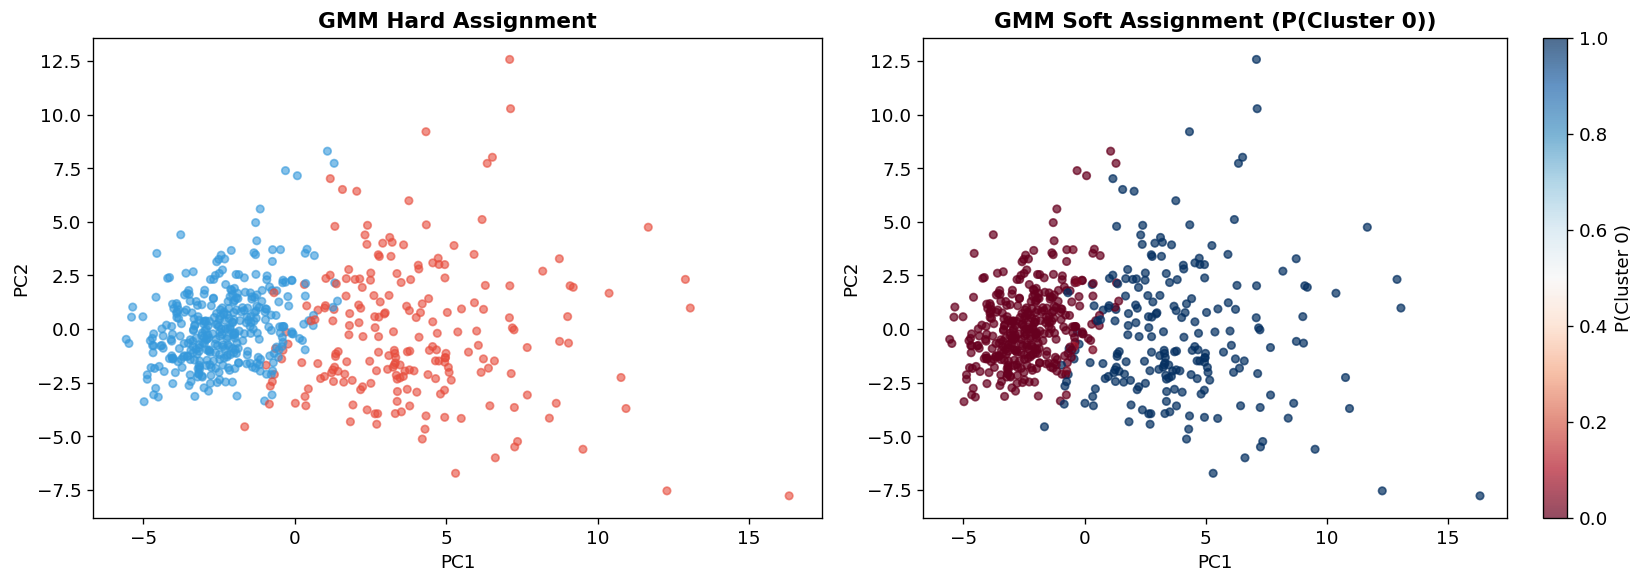

Left: Hard assignment (each patient in exactly one cluster)
Right: Soft assignment (gradient shows probability)
Patients in the transition zone (purple/white) have uncertain membership.

Clinical insight: Borderline patients need closer monitoring — they
may not respond predictably to treatments designed for either subtype.


In [82]:
# --- Visualize GMM: hard vs soft assignment ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hard assignment
colors_gmm = ['#E74C3C' if l == 0 else '#3498DB' for l in gmm_labels]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_gmm, alpha=0.6, s=20)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("GMM Hard Assignment", fontsize=13, fontweight='bold')

# Soft assignment: color by probability of cluster 0
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_probs[:, 0],
                          cmap='RdBu', alpha=0.7, s=20, vmin=0, vmax=1)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("GMM Soft Assignment (P(Cluster 0))", fontsize=13, fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='P(Cluster 0)')

plt.tight_layout()
plt.show()

print("Left: Hard assignment (each patient in exactly one cluster)")
print("Right: Soft assignment (gradient shows probability)")
print("Patients in the transition zone (purple/white) have uncertain membership.")
print("\nClinical insight: Borderline patients need closer monitoring — they")
print("may not respond predictably to treatments designed for either subtype.")


## 7. PCA, t-SNE, and UMAP — Visualization Comparison

Three approaches to reducing 30-dimensional patient data to 2D for visualization:

| Method | Type | Preserves | Speed | Key Parameter |
|--------|------|-----------|-------|---------------|
| **PCA** | Linear | Global variance | Very fast | n_components |
| **t-SNE** | Non-linear | Local neighborhoods | Slow (O(n^2)) | Perplexity |
| **UMAP** | Non-linear | Local + global | Fast | n_neighbors, min_dist |

> **Clinical analogy:**
> - **PCA** = summarizing a patient history in two sentences. You capture the
>   main story but lose subtle details.
> - **t-SNE** = a detailed map of your hospital ward — you know exactly who is
>   next to whom, but distances between wards are distorted.
> - **UMAP** = a city map that preserves both neighborhoods AND the overall
>   layout of the city. The best of both worlds.


In [83]:
# ============================================================
# Section 7: PCA + t-SNE + UMAP Comparison
# ============================================================

# PCA (already computed)
print("Computing dimensionality reductions...")
print("  PCA: done (from Section 3)")

# t-SNE
print("  t-SNE: computing...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print("  t-SNE: done")

# UMAP
print("  UMAP: computing...")
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                     random_state=SEED)
X_umap = reducer.fit_transform(X_scaled)
print("  UMAP: done")

print()
print("All three projections computed. Now let us compare them.")


Computing dimensionality reductions...
  PCA: done (from Section 3)
  t-SNE: computing...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


  t-SNE: done
  UMAP: computing...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP: done

All three projections computed. Now let us compare them.


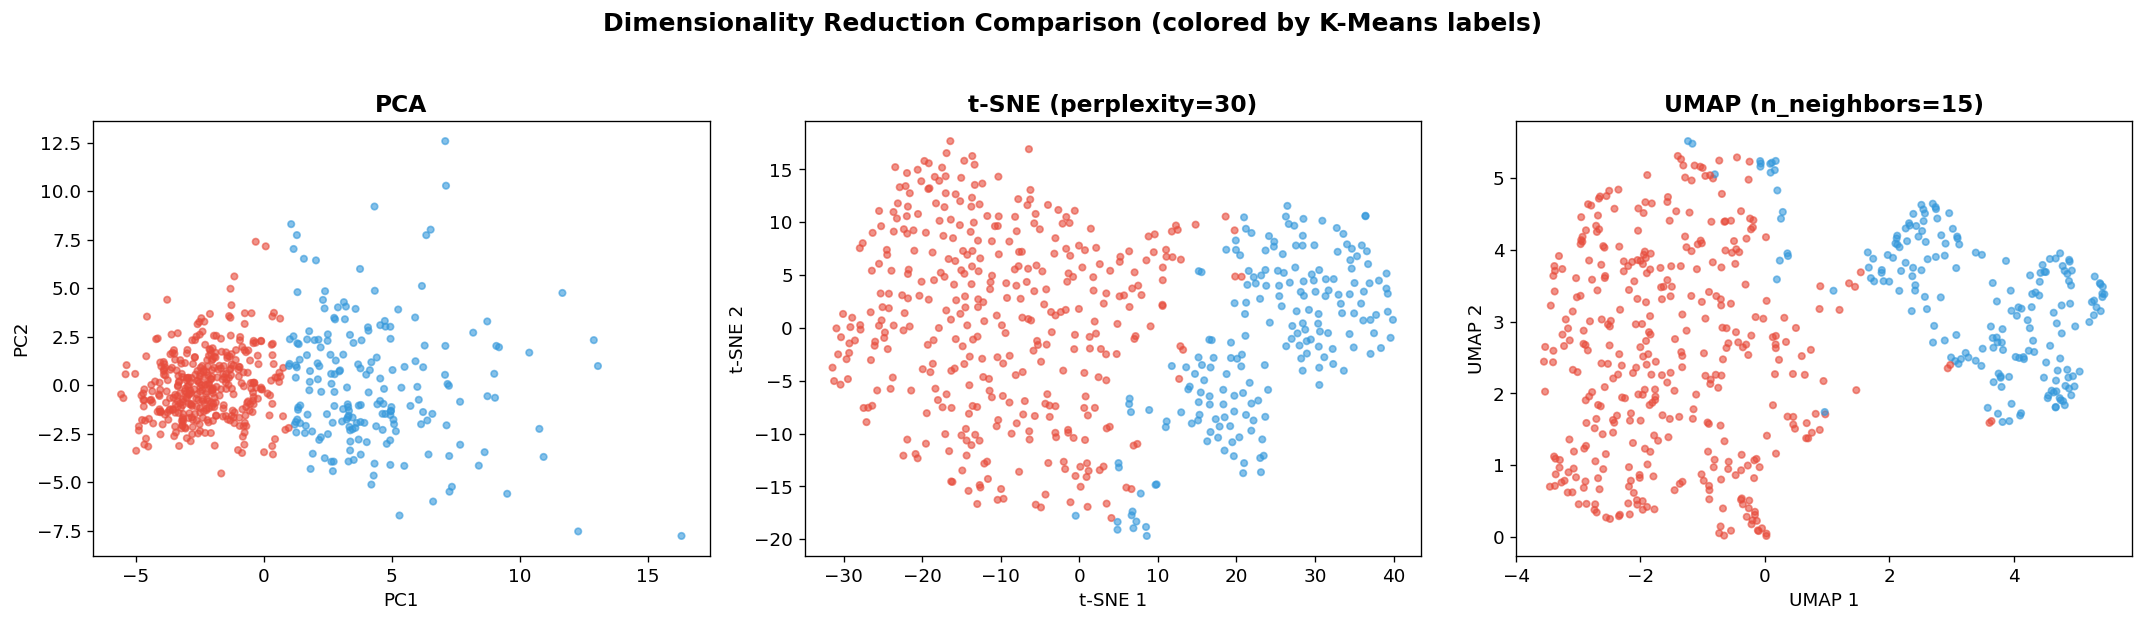

PCA: Linear projection — preserves global structure, may merge local clusters.
t-SNE: Non-linear — excellent local separation, but cluster distances meaningless.
UMAP: Non-linear — preserves both local and global structure, fastest of the three.


In [84]:
# --- Triple comparison: PCA vs t-SNE vs UMAP ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Helper: color by K-Means labels
km_colors = ['#E74C3C' if l == 0 else '#3498DB' for l in km_labels]

# PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=km_colors, alpha=0.6, s=15)
axes[0].set_title("PCA", fontsize=14, fontweight='bold')
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# t-SNE
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=km_colors, alpha=0.6, s=15)
axes[1].set_title("t-SNE (perplexity=30)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

# UMAP
axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=km_colors, alpha=0.6, s=15)
axes[2].set_title("UMAP (n_neighbors=15)", fontsize=14, fontweight='bold')
axes[2].set_xlabel("UMAP 1")
axes[2].set_ylabel("UMAP 2")

fig.suptitle("Dimensionality Reduction Comparison (colored by K-Means labels)",
             fontsize=15, fontweight='bold', y=1.03)

plt.tight_layout()
plt.show()

print("PCA: Linear projection — preserves global structure, may merge local clusters.")
print("t-SNE: Non-linear — excellent local separation, but cluster distances meaningless.")
print("UMAP: Non-linear — preserves both local and global structure, fastest of the three.")


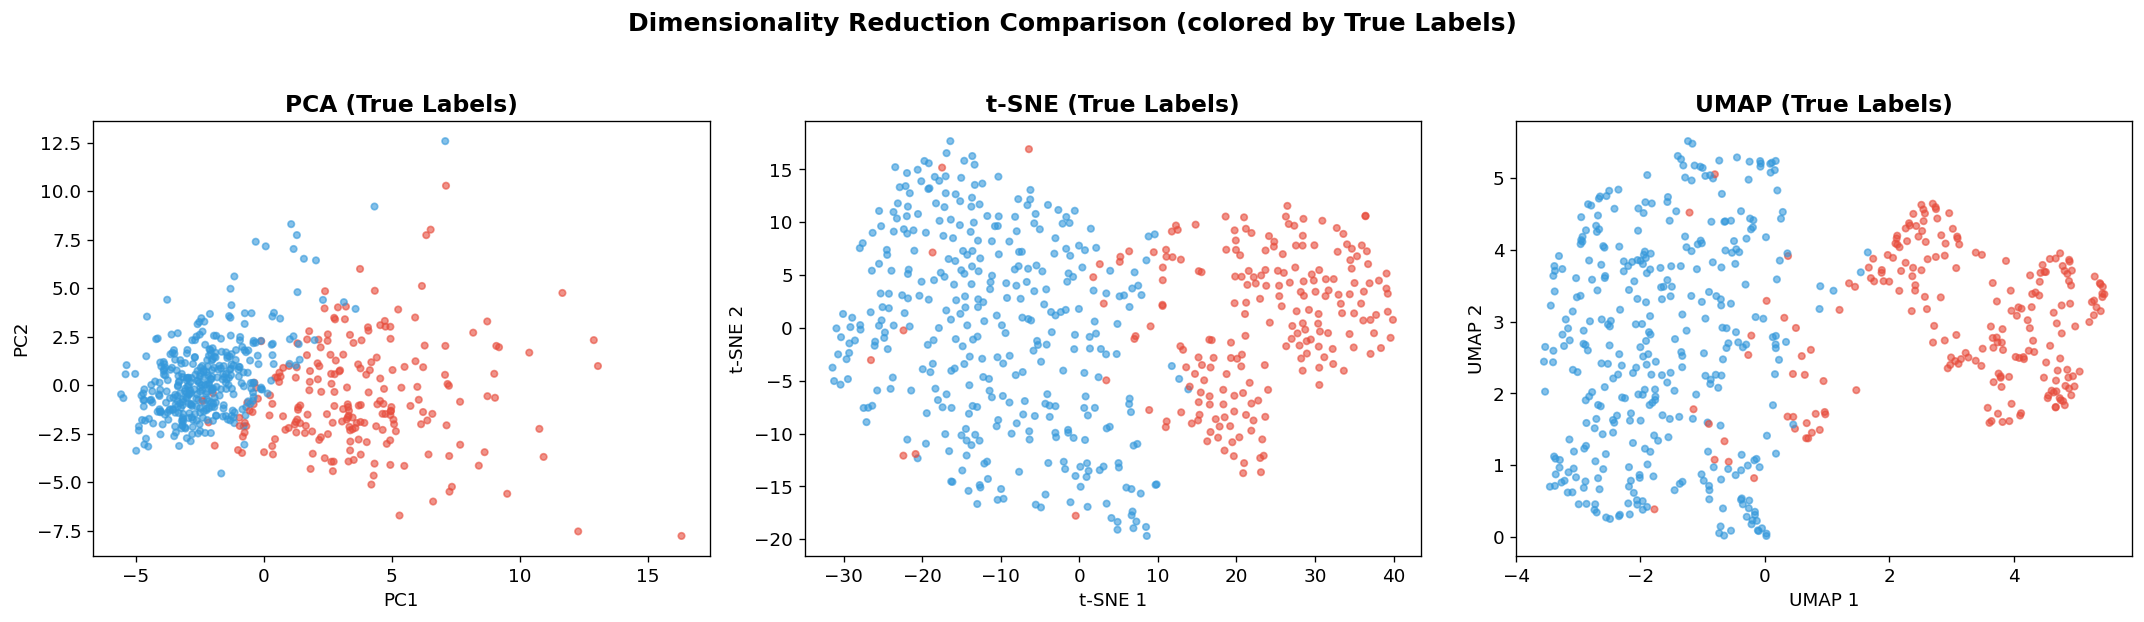

t-SNE and UMAP reveal cluster separation that PCA partially obscures.
This is why non-linear methods are preferred for high-dimensional clinical data.

IMPORTANT caveat: t-SNE cluster DISTANCES and SIZES are meaningless.
Only the SEPARATION between clusters is interpretable.


In [85]:
# --- Same comparison but colored by TRUE labels (for validation) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

true_colors = ['#E74C3C' if l == 0 else '#3498DB' for l in y_cancer]

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=true_colors, alpha=0.6, s=15)
axes[0].set_title("PCA (True Labels)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=true_colors, alpha=0.6, s=15)
axes[1].set_title("t-SNE (True Labels)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=true_colors, alpha=0.6, s=15)
axes[2].set_title("UMAP (True Labels)", fontsize=14, fontweight='bold')
axes[2].set_xlabel("UMAP 1")
axes[2].set_ylabel("UMAP 2")

fig.suptitle("Dimensionality Reduction Comparison (colored by True Labels)",
             fontsize=15, fontweight='bold', y=1.03)

plt.tight_layout()
plt.show()

print("t-SNE and UMAP reveal cluster separation that PCA partially obscures.")
print("This is why non-linear methods are preferred for high-dimensional clinical data.")
print()
print("IMPORTANT caveat: t-SNE cluster DISTANCES and SIZES are meaningless.")
print("Only the SEPARATION between clusters is interpretable.")


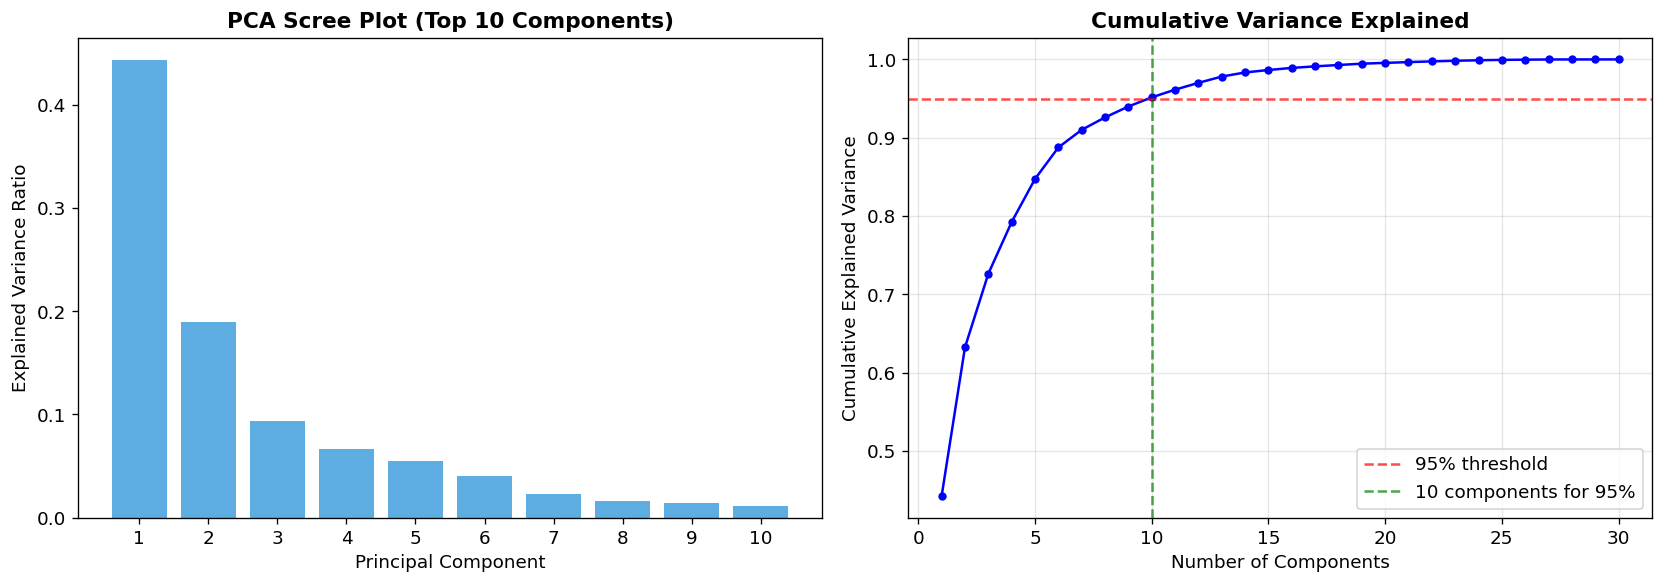

PC1 explains 44.3% of variance
PC1 + PC2 explain 63.2% of variance
Need 10 components for 95% of variance

If PC1 + PC2 explain 85%+ of variance, PCA plots are fairly trustworthy.
If only 40%, you should rely more on t-SNE or UMAP.


In [86]:
# --- PCA explained variance analysis ---
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 11), pca_full.explained_variance_ratio_[:10],
            color='#3498DB', alpha=0.8)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("PCA Scree Plot (Top 10 Components)", fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, 11))

# Cumulative variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar) + 1), cumvar, 'bo-', markersize=4)
axes[1].axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
n_95 = np.argmax(cumvar >= 0.95) + 1
axes[1].axvline(x=n_95, color='green', linestyle='--', alpha=0.7,
                label=f'{n_95} components for 95%')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Variance Explained", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PC1 explains {pca_full.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PC1 + PC2 explain {sum(pca_full.explained_variance_ratio_[:2])*100:.1f}% of variance")
print(f"Need {n_95} components for 95% of variance")
print()
print("If PC1 + PC2 explain 85%+ of variance, PCA plots are fairly trustworthy.")
print("If only 40%, you should rely more on t-SNE or UMAP.")


## 8. Student Tasks

Complete the following exercises to deepen your understanding of unsupervised
learning. Each task builds on the code from previous sections.

---

### Task 1: GMM Soft vs Hard Assignment (Difficulty: ⭐)

Apply Gaussian Mixture Model with K=2 and compare:
- Hard assignment labels vs K-Means labels
- Soft assignment probabilities — which patients are most uncertain?
- Hint: Use `gmm.predict_proba()` and find patients where max probability < 0.7

### Task 2: UMAP Parameter Exploration (Difficulty: ⭐)

Vary `n_neighbors` in UMAP (try 5, 15, 50) and observe:
- How does the visualization change?
- Which setting reveals the clearest cluster separation?
- Hint: Smaller n_neighbors preserves more local structure

### Task 3: External Validation with ARI and NMI (Difficulty: ⭐⭐)

Compare clustering results to true labels using:
- `adjusted_rand_score` (ARI): chance-adjusted measure of agreement
- `normalized_mutual_info_score` (NMI): information-theoretic measure
- Compare K-Means, Hierarchical, DBSCAN, and GMM

### Task 4: HDBSCAN vs DBSCAN (Difficulty: ⭐⭐)

Apply HDBSCAN (from the `hdbscan` library) and compare:
- Does it handle noise better than DBSCAN?
- How many clusters does it find automatically?
- Hint: `!pip install hdbscan --quiet` then `hdbscan.HDBSCAN(min_cluster_size=15)`

### Task 5: Simple Autoencoder for Dim Reduction (Difficulty: ⭐⭐⭐)

Build a simple Dense autoencoder using Keras:
- Encoder: 30 -> 16 -> 8 -> 2 (bottleneck)
- Decoder: 2 -> 8 -> 16 -> 30
- Train on X_scaled, then extract 2D bottleneck features
- Cluster the bottleneck features and compare to PCA/UMAP


Task 1: GMM Soft Assignment Analysis
Patients with max probability < 0.70: 0
These borderline patients (0.0%) have
uncertain cluster membership — clinically the most interesting.



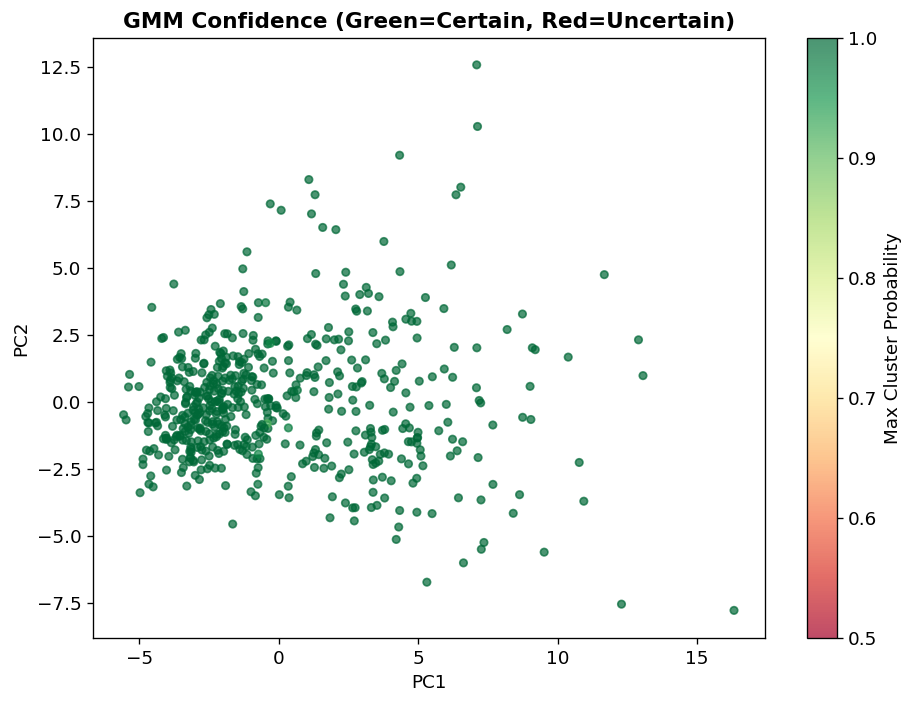

Green points: confidently assigned to one cluster
Red/yellow points: borderline — could belong to either cluster

YOUR TURN: Compare gmm_labels with km_labels.
How many patients are assigned differently by the two methods?


<Figure size 1440x600 with 0 Axes>

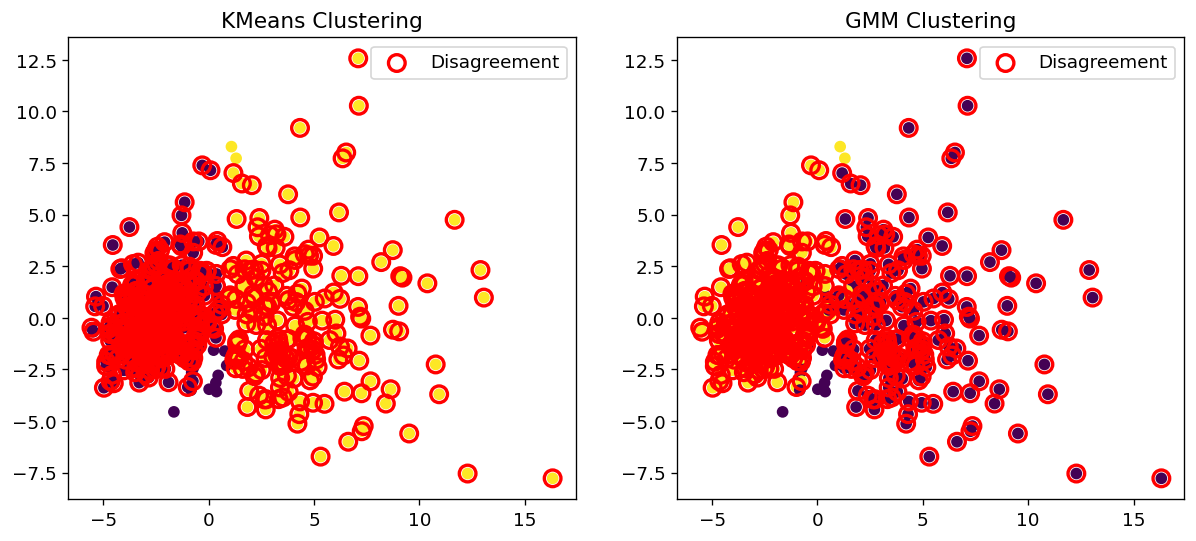

In [87]:
# ============================================================
# Task 1: GMM Soft vs Hard Assignment (Starter Code)
# ============================================================

# GMM is already fitted from Section 6
# Find the most uncertain patients
max_probs = np.max(gmm_probs, axis=1)
uncertain_mask = max_probs < 0.70
n_uncertain = sum(uncertain_mask)

print(f"Task 1: GMM Soft Assignment Analysis")
print(f"=" * 50)
print(f"Patients with max probability < 0.70: {n_uncertain}")
print(f"These borderline patients ({n_uncertain/len(gmm_probs)*100:.1f}%) have")
print(f"uncertain cluster membership — clinically the most interesting.")
print()

# Visualize uncertainty
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=max_probs,
                     cmap='RdYlGn', alpha=0.7, s=20, vmin=0.5, vmax=1.0)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("GMM Confidence (Green=Certain, Red=Uncertain)",
             fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Max Cluster Probability')
plt.tight_layout()
plt.show()

print("Green points: confidently assigned to one cluster")
print("Red/yellow points: borderline — could belong to either cluster")
print()
print("YOUR TURN: Compare gmm_labels with km_labels.")
print("How many patients are assigned differently by the two methods?")
disagreements = sum(gmm_labels != km_labels)  # Uncomment and check

plt.figure(figsize=(12,5))

diff = km_labels != gmm_labels

plt.figure(figsize=(12,5))

# KMeans
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=km_labels, cmap='viridis')
plt.scatter(
    X_pca[diff,0], X_pca[diff,1],
    facecolors='none', edgecolors='red', s=100, linewidths=2,
    label='Disagreement'
)
plt.title("KMeans Clustering")
plt.legend()

# GMM
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=gmm_labels, cmap='viridis')
plt.scatter(
    X_pca[diff,0], X_pca[diff,1],
    facecolors='none', edgecolors='red', s=100, linewidths=2,
    label='Disagreement'
)
plt.title("GMM Clustering")
plt.legend()

plt.show()

Task 2: Effect of n_neighbors on UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


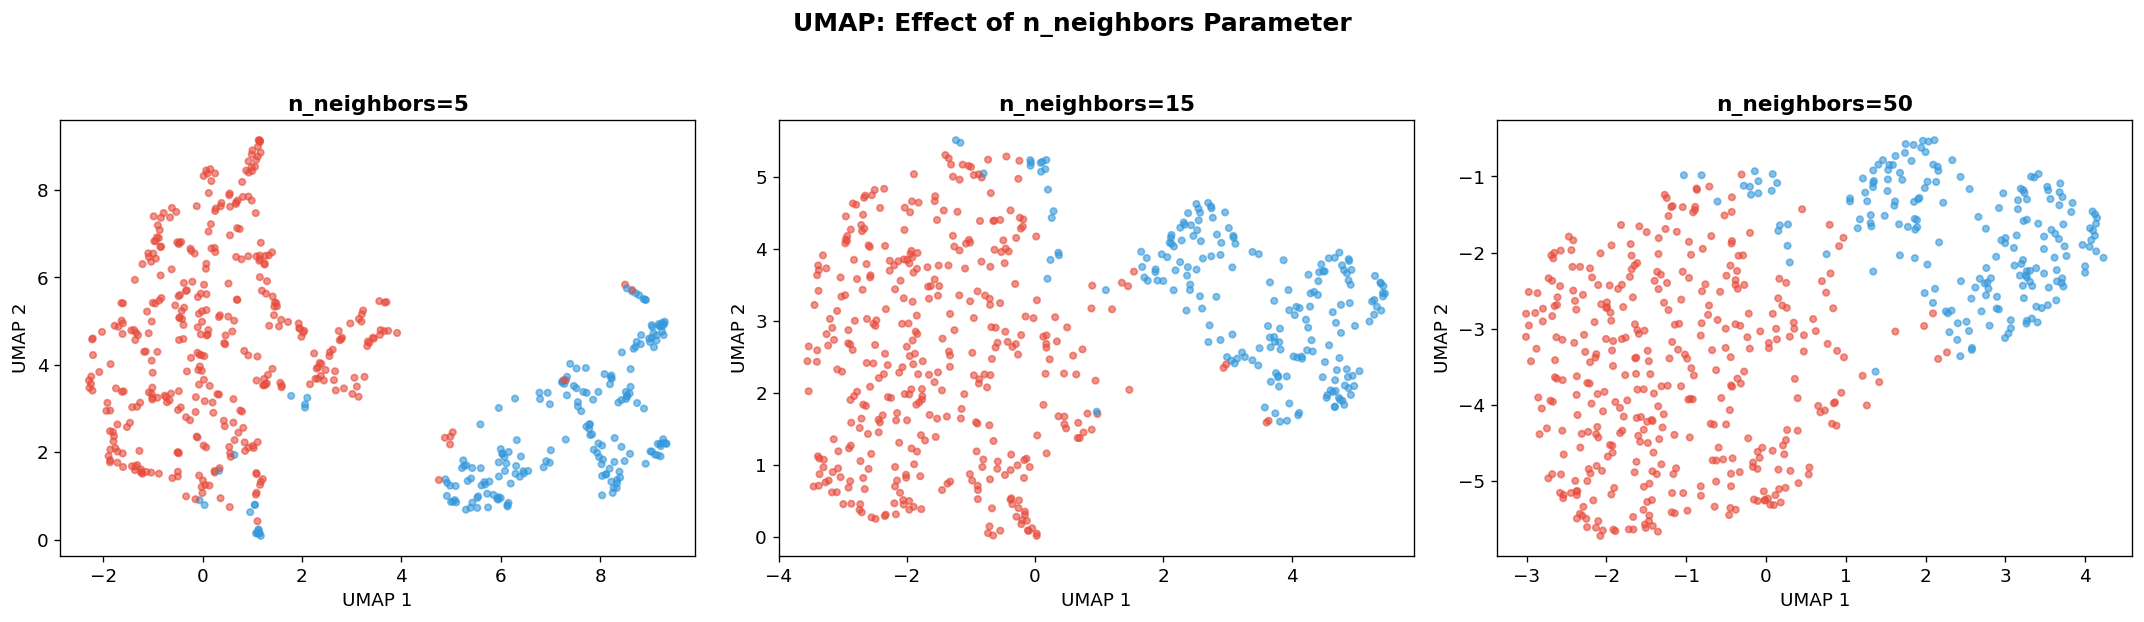

n_neighbors=5:  More local structure, tighter clusters, more fragmentation
n_neighbors=15: Balanced local and global structure (default)
n_neighbors=50: More global structure, smoother layout

YOUR TURN: Which n_neighbors value reveals the clearest separation?
Try also varying min_dist (0.01, 0.1, 0.5) and observe the effect.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

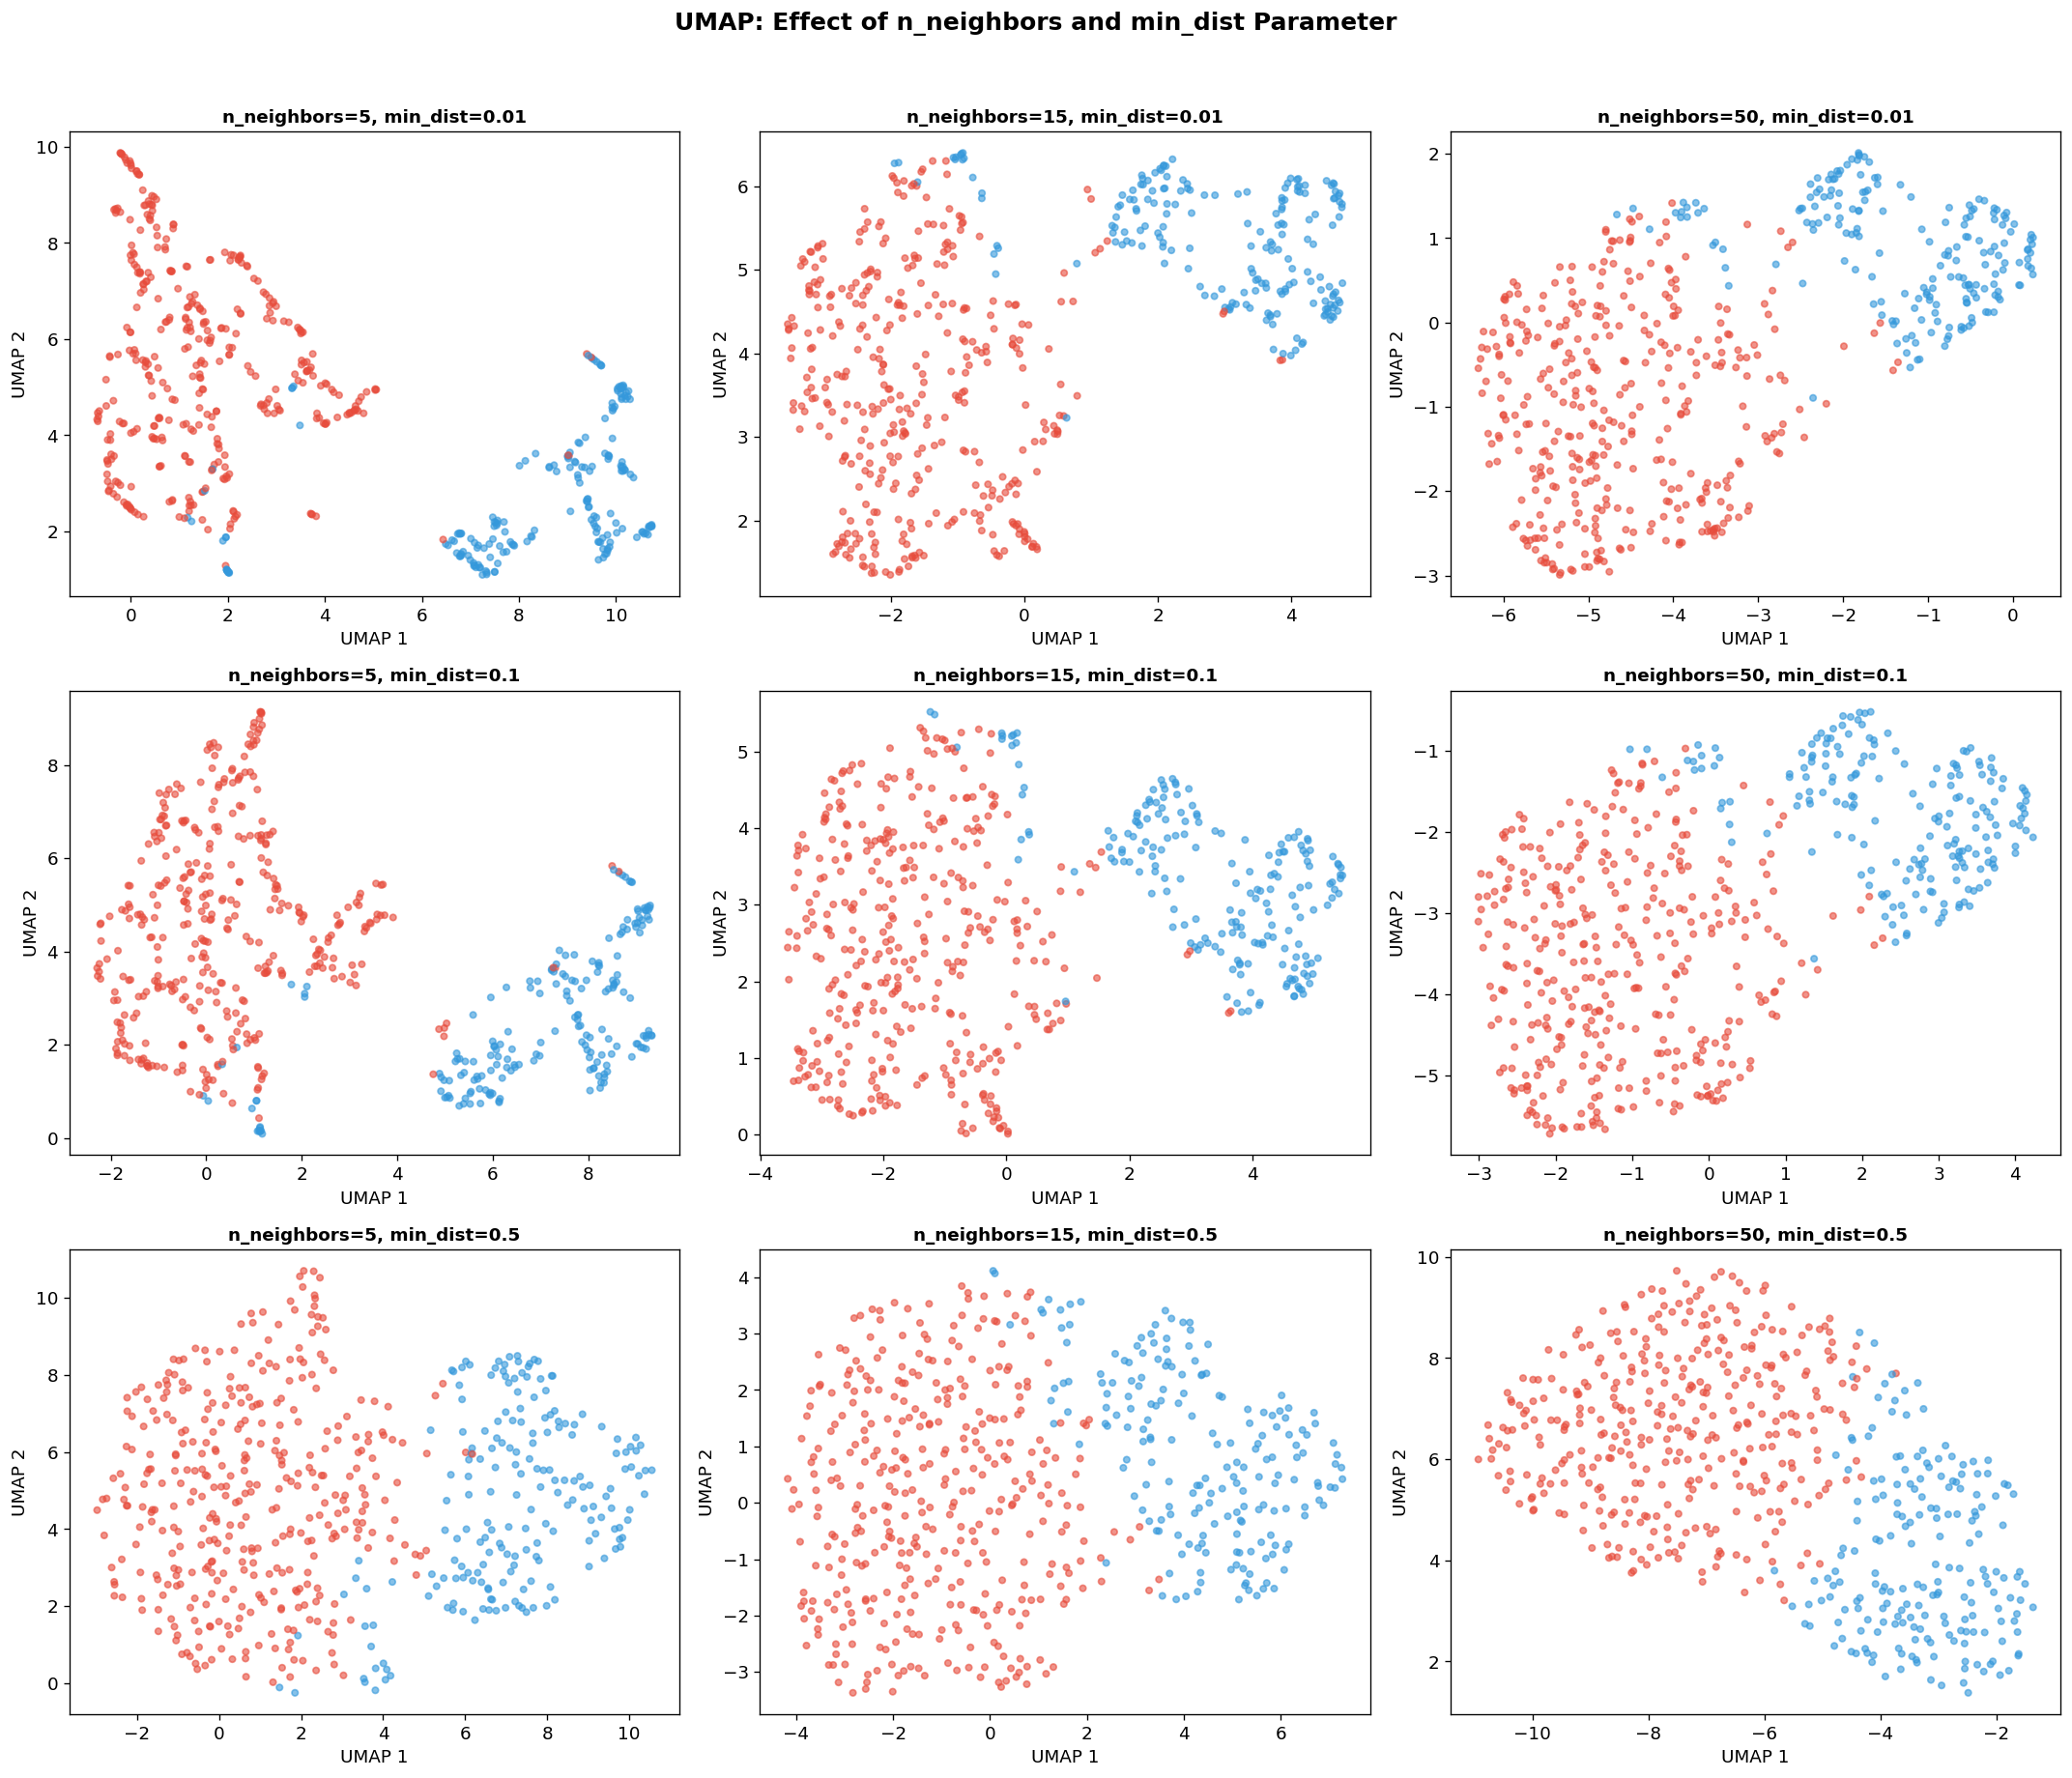

In [88]:
# ============================================================
# Task 2: UMAP Parameter Exploration (Starter Code)
# ============================================================

print("Task 2: Effect of n_neighbors on UMAP")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
n_neighbors_list = [5, 15, 50]

for idx, nn in enumerate(n_neighbors_list):
    reducer_test = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1,
                              random_state=SEED)
    X_umap_test = reducer_test.fit_transform(X_scaled)

    km_colors_task = ['#E74C3C' if l == 0 else '#3498DB' for l in km_labels]
    axes[idx].scatter(X_umap_test[:, 0], X_umap_test[:, 1],
                      c=km_colors_task, alpha=0.6, s=15)
    axes[idx].set_title(f"n_neighbors={nn}", fontsize=13, fontweight='bold')
    axes[idx].set_xlabel("UMAP 1")
    axes[idx].set_ylabel("UMAP 2")

plt.suptitle("UMAP: Effect of n_neighbors Parameter",
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("n_neighbors=5:  More local structure, tighter clusters, more fragmentation")
print("n_neighbors=15: Balanced local and global structure (default)")
print("n_neighbors=50: More global structure, smoother layout")
print()
print("YOUR TURN: Which n_neighbors value reveals the clearest separation?")
print("Try also varying min_dist (0.01, 0.1, 0.5) and observe the effect.")

fig, axes = plt.subplots(3, 3, figsize=(18,15))
min_dist_set = [0.01, 0.1, 0.5]

km_colors_task = ['#E74C3C' if l == 0 else '#3498DB' for l in km_labels]

for row, md in enumerate(min_dist_set):
    for col, nn in enumerate(n_neighbors_list):
        reducer_test = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=md, random_state=SEED)
        X_umap_test = reducer_test.fit_transform(X_scaled)
        ax = axes[row, col]

        ax.scatter(
            X_umap_test[:, 0],
            X_umap_test[:, 1],
            c=km_colors_task,
            alpha=0.6,
            s=15
        )

        ax.set_title(
            f"n_neighbors={nn}, min_dist={md}",
            fontsize=11,
            fontweight='bold'
        )
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")

plt.suptitle(
    "UMAP: Effect of n_neighbors and min_dist Parameter",
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

Task 3: Comparing All Methods with External Validation
Method                 Silhouette      ARI      NMI
------------------------------------------------------------
K-Means (K=2)              0.3434   0.6536   0.5324
Hierarchical               0.3394   0.5750   0.4569
GMM                        0.3145   0.7740   0.6611
DBSCAN                        N/A      N/A      N/A

Higher ARI and NMI = better agreement with true labels.
But remember: in real unsupervised learning, we do NOT have true labels!
Silhouette score is the only metric we can compute without labels.

YOUR TURN: Which method best recovers the true structure?
Does the highest silhouette score correspond to the highest ARI?
Q1: GMM performs the best in recovering the true structure, as it achieves the highest ARI (0.7740) and NMI (0.6611).
Q2: No, the method with the highest silhouette score is K-Means (0.3434), but it does not have the highest ARI. This shows that silhouette score does not always reflect agreement with t

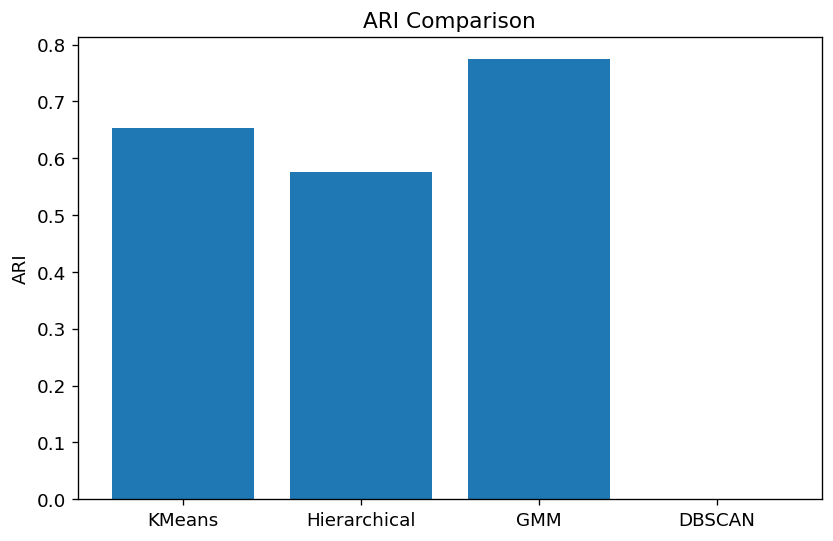

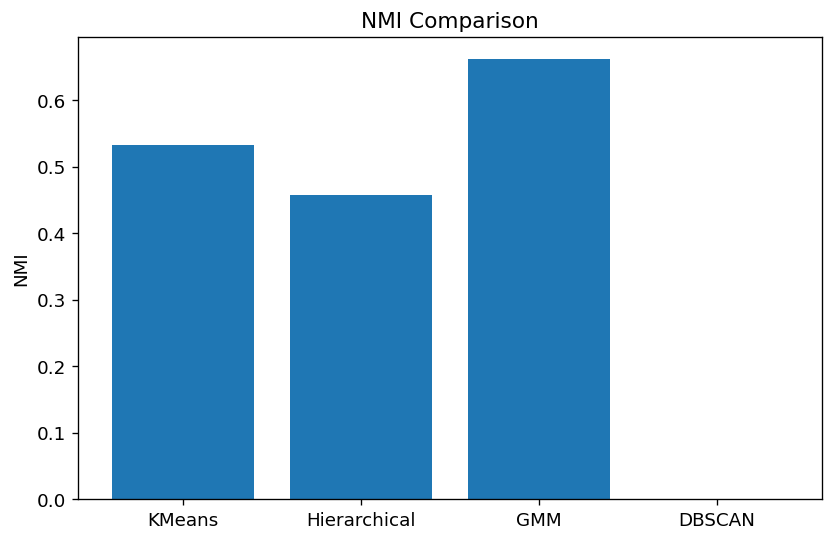

In [89]:
# ============================================================
# Task 3: External Validation (Starter Code)
# ============================================================

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print("Task 3: Comparing All Methods with External Validation")
print("=" * 60)
print(f"{'Method':<20} {'Silhouette':>12} {'ARI':>8} {'NMI':>8}")
print("-" * 60)

# K-Means
sil_km = silhouette_score(X_scaled, km_labels)
ari_km = adjusted_rand_score(y_cancer, km_labels)
nmi_km = normalized_mutual_info_score(y_cancer, km_labels)
print(f"{'K-Means (K=2)':<20} {sil_km:>12.4f} {ari_km:>8.4f} {nmi_km:>8.4f}")

# Hierarchical
sil_agg2 = silhouette_score(X_scaled, agg_labels)
ari_agg2 = adjusted_rand_score(y_cancer, agg_labels)
nmi_agg2 = normalized_mutual_info_score(y_cancer, agg_labels)
print(f"{'Hierarchical':<20} {sil_agg2:>12.4f} {ari_agg2:>8.4f} {nmi_agg2:>8.4f}")

# GMM
sil_gmm2 = silhouette_score(X_scaled, gmm_labels)
ari_gmm2 = adjusted_rand_score(y_cancer, gmm_labels)
nmi_gmm2 = normalized_mutual_info_score(y_cancer, gmm_labels)
print(f"{'GMM':<20} {sil_gmm2:>12.4f} {ari_gmm2:>8.4f} {nmi_gmm2:>8.4f}")

# DBSCAN (only non-noise points)
non_noise = db_labels != -1
if sum(non_noise) > 1 and len(set(db_labels[non_noise])) > 1:
    sil_db = silhouette_score(X_pca10[non_noise], db_labels[non_noise])
    ari_db = adjusted_rand_score(y_cancer[non_noise], db_labels[non_noise])
    nmi_db = normalized_mutual_info_score(y_cancer[non_noise], db_labels[non_noise])
    print(f"{'DBSCAN':<20} {sil_db:>12.4f} {ari_db:>8.4f} {nmi_db:>8.4f}")
else:
    nmi_db = 0
    ari_db = 0
    print(f"{'DBSCAN':<20} {'N/A':>12} {'N/A':>8} {'N/A':>8}")

print()
print("Higher ARI and NMI = better agreement with true labels.")
print("But remember: in real unsupervised learning, we do NOT have true labels!")
print("Silhouette score is the only metric we can compute without labels.")
print()
print("YOUR TURN: Which method best recovers the true structure?")
print("Does the highest silhouette score correspond to the highest ARI?")

print("Q1: GMM performs the best in recovering the true structure, as it achieves the highest ARI (0.7740) and NMI (0.6611).")
print("Q2: No, the method with the highest silhouette score is K-Means (0.3434), but it does not have the highest ARI. This shows that silhouette score does not always reflect agreement with true labels, since it only measures cluster compactness and separation, not correctness.")


methods = ["KMeans", "Hierarchical", "GMM", "DBSCAN"]
ari = [ari_km, ari_agg2, ari_gmm2, ari_db]
nmi = [nmi_km, nmi_agg2, nmi_gmm2, nmi_db]

plt.figure(figsize=(8,5))
plt.bar(methods, ari)
plt.title("ARI Comparison")
plt.ylabel("ARI")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(methods, nmi)
plt.title("NMI Comparison")
plt.ylabel("NMI")
plt.show()

[-1 -1 -1 -1 -1 -1  0 -1 -1 -1  1 -1 -1 -1 -1 -1  1 -1 -1  1  1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1  1 -1 -1 -1 -1
  1  1  1  1  1 -1  1  1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1  1 -1 -1
 -1  1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1  1 -1  1 -1  1  1 -1 -1
 -1 -1  1 -1  1 -1  1  1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1
  1 -1 -1  1 -1  1 -1 -1 -1 -1  1  0 -1  1 -1  1 -1  1 -1 -1 -1 -1  1  1
  1 -1 -1 -1  1  1 -1 -1 -1  1  1  1 -1 -1  1  1 -1 -1 -1 -1 -1  1 -1 -1
 -1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1  1 -1 -1
 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1  1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1
 -1 -1 -1 -1  1  1  1  1  1 -1  1  1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1
  1  1 -1 -1 -1 -1  1 -1 -1  1 -1  1 -1  0  0  1 -1 -1 -1 -1 -1 -1 -1  1
 -1 -1 -1  1  1 -1  1  1 -1 -1 -1 -1  1 -1  1  1 -1 -1  0 -1 -1  1 -1  1
 -1  1 -1  1 -1  1  1  1 -1 -1  1 -1 -1 -1 -1  1  1 -1  1 -1  1  1  1  1
  1 -1 -1  1  1  0 -1 -1 -1 -1 -1 -1  1  1  1  1 -1

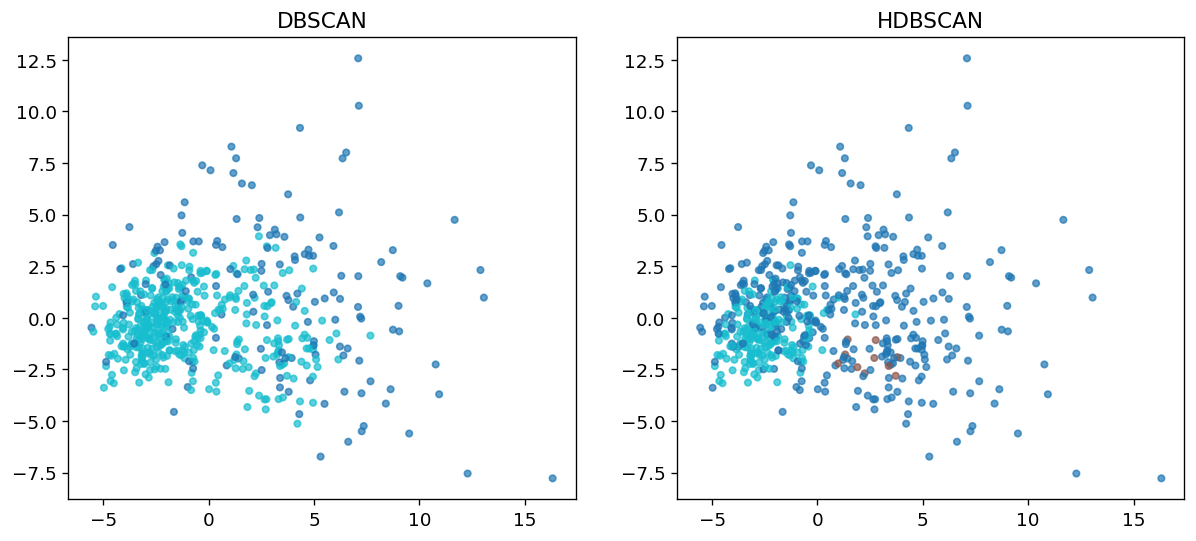

In [90]:
# ============================================================
# Task 4: HDBSCAN vs DBSCAN
# ============================================================

!pip install hdbscan --quiet
import hdbscan

hdb = hdbscan.HDBSCAN(min_cluster_size=5)
hdb_labels = hdb.fit_predict(X_scaled)

print(hdb_labels)

n_clusters_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise_hdb = np.sum(hdb_labels == -1)

print("HDBSCAN number of clusters:", n_clusters_hdb)
print("HDBSCAN number of noise points:", n_noise_hdb)
print("HDBSCAN noise ratio:", n_noise_hdb / len(hdb_labels))


n_clusters_dbscan = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_dbscan = np.sum(db_labels == -1)

print("DBSCAN number of clusters:", n_clusters_dbscan)
print("DBSCAN number of noise points:", n_noise_dbscan)
print("DBSCAN noise ratio:", n_noise_dbscan / len(db_labels))


comparison = pd.DataFrame({
    "Method": ["DBSCAN", "HDBSCAN"],
    "Number of clusters": [n_clusters_dbscan, n_clusters_hdb],
    "Noise points": [n_noise_dbscan, n_noise_hdb],
    "Noise ratio": [
        n_noise_dbscan / len(db_labels),
        n_noise_hdb / len(hdb_labels)
    ]
})

print(comparison)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels, cmap="tab10", s=15, alpha=0.7)
plt.title("DBSCAN")

plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=hdb_labels, cmap="tab10", s=15, alpha=0.7)
plt.title("HDBSCAN")

plt.show()


Task 5: Simple Autoencoder for Dimensionality Reduction


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 2)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,328 (5.19 KB)

 Trainable params: 1,328 (5.19 KB)

 Non-trainable params: 0 (0.00 B)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
(569, 2)
Autoencoder + KMeans
Silhouette: 0.5022171
ARI: 0.5504120976446464
NMI: 0.4943017260988455


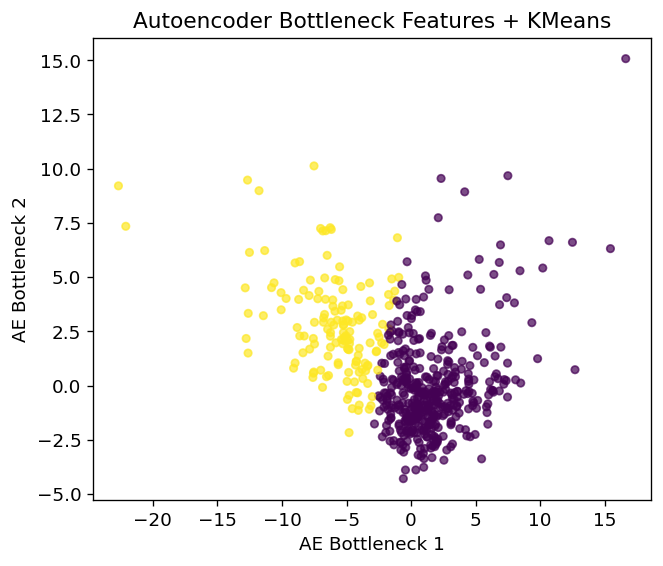

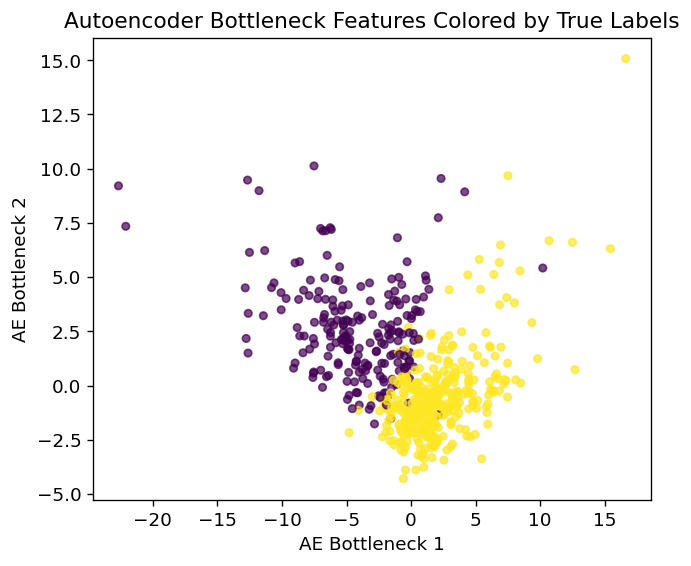

,Method,Silhouette,ARI,NMI
0,PCA + KMeans,0.506599,0.653625,0.532408
1,UMAP + KMeans,0.528490,0.653625,0.532408
2,Autoencoder + KMeans,0.502217,0.550412,0.494302


In [91]:
# ================================================================
# Task 5: Simple Autoencoder for Dim Reduction (Difficulty: ⭐⭐⭐)
# ================================================================

# Build a simple Dense autoencoder using Keras:
# Encoder: 30 -> 16 -> 8 -> 2 (bottleneck)
# Decoder: 2 -> 8 -> 16 -> 30
# Train on X_scaled, then extract 2D bottleneck features
# Cluster the bottleneck features and compare to PCA/UMAP

from tensorflow import keras
from tensorflow.keras import layers

print("Task 5: Simple Autoencoder for Dimensionality Reduction")
print("=" * 60)


input_dim = X_scaled.shape[1]


input_layer = keras.Input(shape=(input_dim,))

# Encoder: 30 -> 16 -> 8 -> 2
encoded = layers.Dense(16, activation="relu")(input_layer)
encoded = layers.Dense(8, activation="relu")(encoded)
bottleneck = layers.Dense(2, activation="linear", name="bottleneck")(encoded)

# Decoder: 2 -> 8 -> 16 -> 30
decoded = layers.Dense(8, activation="relu")(bottleneck)
decoded = layers.Dense(16, activation="relu")(decoded)
output_layer = layers.Dense(input_dim, activation="linear")(decoded)

autoencoder = keras.Model(input_layer, output_layer)
encoder = keras.Model(input_layer, bottleneck)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

X_ae = encoder.predict(X_scaled)
print(X_ae.shape)

km_ae = KMeans(n_clusters=2, random_state=SEED, n_init=10)
ae_labels = km_ae.fit_predict(X_ae)

sil_ae = silhouette_score(X_ae, ae_labels)
ari_ae = adjusted_rand_score(y_cancer, ae_labels)
nmi_ae = normalized_mutual_info_score(y_cancer, ae_labels)

print("Autoencoder + KMeans")
print("Silhouette:", sil_ae)
print("ARI:", ari_ae)
print("NMI:", nmi_ae)

plt.figure(figsize=(6,5))
plt.scatter(
    X_ae[:, 0],
    X_ae[:, 1],
    c=ae_labels,
    cmap="viridis",
    alpha=0.7,
    s=20
)
plt.xlabel("AE Bottleneck 1")
plt.ylabel("AE Bottleneck 2")
plt.title("Autoencoder Bottleneck Features + KMeans")
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(
    X_ae[:, 0],
    X_ae[:, 1],
    c=y_cancer,
    cmap="viridis",
    alpha=0.7,
    s=20
)
plt.xlabel("AE Bottleneck 1")
plt.ylabel("AE Bottleneck 2")
plt.title("Autoencoder Bottleneck Features Colored by True Labels")
plt.show()


compare_df = pd.DataFrame({
    "Method": ["PCA + KMeans", "UMAP + KMeans", "Autoencoder + KMeans"],
    "Silhouette": [
        silhouette_score(X_pca[:, :2], km_labels),
        silhouette_score(X_umap, km_labels),
        sil_ae
    ],
    "ARI": [
        adjusted_rand_score(y_cancer, km_labels),
        adjusted_rand_score(y_cancer, km_labels),
        ari_ae
    ],
    "NMI": [
        normalized_mutual_info_score(y_cancer, km_labels),
        normalized_mutual_info_score(y_cancer, km_labels),
        nmi_ae
    ]
})

compare_df




## 9. Gemini AI Exercise

Use Gemini AI as a **clustering consultant** — asking about algorithm
selection, parameter tuning, and clinical interpretation of results.

The three prompts below cover the key decisions in any clustering project:
1. **Which algorithm?** (K-Means vs DBSCAN)
2. **Are the results good?** (silhouette score interpretation)
3. **Which visualization to trust?** (PCA vs t-SNE vs UMAP)


In [92]:
# ============================================================
# Section 9: Gemini AI Exercise
# ============================================================

# --- Prompt 1: Algorithm Selection ---
prompt_1 = (
    "Explain the difference between K-means and DBSCAN clustering for "
    "patient stratification. When would you choose each in a clinical "
    "setting? Give a concrete diabetes subtyping example."
)

# --- Prompt 2: Interpret Clustering Quality ---
prompt_2 = (
    "I have patient clusters with silhouette score 0.35 -- is this good "
    "or bad? How would I validate these clusters clinically? "
    "Suggest 3 validation strategies for diabetes subtypes."
)

# --- Prompt 3: Dimensionality Reduction Choice ---
prompt_3 = (
    "Compare PCA, t-SNE, and UMAP for visualizing 30-dimensional patient "
    "data. What does each preserve and what does each distort? Which should "
    "I trust for clinical interpretation of clustering results?"
)

try:
    from google.colab import ai

    print("Prompt 1: Algorithm Selection")
    print("=" * 60)
    response_1 = ai.generate_text(prompt_1)
    print(response_1)

    print()
    print("Prompt 2: Interpreting Clustering Quality")
    print("=" * 60)
    response_2 = ai.generate_text(prompt_2)
    print(response_2)

    print()
    print("Prompt 3: Dimensionality Reduction Choice")
    print("=" * 60)
    response_3 = ai.generate_text(prompt_3)
    print(response_3)

except ImportError:
    print("Gemini AI not available (not running in Google Colab).")
    print("To use Gemini, run this notebook in Google Colab.")
    print()
    print("Prompts to try when you have access:")
    print()
    print(f"Prompt 1: {prompt_1}")
    print()
    print(f"Prompt 2: {prompt_2}")
    print()
    print(f"Prompt 3: {prompt_3}")
    print()
    print("Learning goal: Use AI as a clustering consultant -- asking about")
    print("algorithm selection, parameter tuning, and clinical validation of")
    print("discovered patient subtypes.")


Prompt 1: Algorithm Selection
K-means and DBSCAN are both popular clustering algorithms, but they operate on fundamentally different principles, making them suitable for different scenarios in patient stratification.

### K-means Clustering

**How it Works:**
K-means is a **centroid-based** clustering algorithm. It aims to partition $N$ data points into $K$ clusters, where each data point belongs to the cluster with the nearest mean (centroid).
1.  **Initialization:** Choose $K$ initial centroids randomly.
2.  **Assignment Step:** Each data point is assigned to the cluster whose centroid is closest (e.g., using Euclidean distance).
3.  **Update Step:** The centroids are re-calculated as the mean of all data points assigned to that cluster.
4.  **Iteration:** Steps 2 and 3 are repeated until the centroids no longer change significantly or a maximum number of iterations is reached.

**Key Characteristics:**
*   **Requires $K$ (number of clusters) as input:** You must specify how many clu

## 10. Bonus: Deep Embedded Clustering (Conceptual Demo)

**Deep Embedded Clustering (DEC)** jointly learns feature representations
and cluster assignments using a neural network:

1. Train an autoencoder to compress high-dimensional data into a low-dimensional
   latent space (bottleneck)
2. Initialize clusters in the latent space using K-Means
3. Jointly optimize the autoencoder and cluster assignments

**Why it matters in medicine:**
- CDEC achieved NMI of **0.645** for medical image modality classification
- X-DEC produces stable, clinically recognizable ICU patient clusters
- Captures non-linear relationships that K-Means on raw features misses

> This is a **conceptual** demo using a simple Dense autoencoder.
> A full DEC implementation would add the KL-divergence clustering loss.


In [93]:
# ============================================================
# Section 10: Bonus — Simple Autoencoder for Dimensionality Reduction
# ============================================================

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    # Simple autoencoder: 30 -> 16 -> 2 -> 16 -> 30
    input_dim = X_scaled.shape[1]
    encoding_dim = 2

    # Encoder
    encoder_input = keras.Input(shape=(input_dim,))
    x = layers.Dense(16, activation='relu')(encoder_input)
    x = layers.Dense(8, activation='relu')(x)
    encoded = layers.Dense(encoding_dim, activation='linear', name='bottleneck')(x)

    # Decoder
    x = layers.Dense(8, activation='relu')(encoded)
    x = layers.Dense(16, activation='relu')(x)
    decoded = layers.Dense(input_dim, activation='linear')(x)

    # Full autoencoder
    autoencoder = keras.Model(encoder_input, decoded)
    encoder = keras.Model(encoder_input, encoded)

    autoencoder.compile(optimizer='adam', loss='mse')
    print("Autoencoder architecture:")
    autoencoder.summary()

    # Train
    print("\nTraining autoencoder...")
    history = autoencoder.fit(X_scaled, X_scaled,
                              epochs=100, batch_size=32,
                              validation_split=0.2,
                              verbose=0)

    # Extract bottleneck features
    X_encoded = encoder.predict(X_scaled, verbose=0)
    print(f"Bottleneck features shape: {X_encoded.shape}")

    # Cluster bottleneck features
    km_ae = KMeans(n_clusters=2, random_state=SEED, n_init=10)
    ae_labels = km_ae.fit_predict(X_encoded)

    sil_ae = silhouette_score(X_encoded, ae_labels)
    ari_ae = adjusted_rand_score(y_cancer, ae_labels)
    print(f"Autoencoder + K-Means: Silhouette={sil_ae:.4f}, ARI={ari_ae:.4f}")

except ImportError:
    print("TensorFlow not available. Skipping autoencoder demo.")
    print("In Google Colab, TensorFlow is pre-installed.")
    print()
    print("Conceptual summary of Deep Embedded Clustering (DEC):")
    print("  1. Autoencoder compresses 30 features to 2D bottleneck")
    print("  2. K-Means initializes clusters in bottleneck space")
    print("  3. Joint optimization refines both representation AND clusters")
    print("  4. Result: non-linear feature learning + clustering in one model")
    X_encoded = None
    ae_labels = None


Autoencoder architecture:


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 2)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,328 (5.19 KB)

 Trainable params: 1,328 (5.19 KB)

 Non-trainable params: 0 (0.00 B)


Training autoencoder...
Bottleneck features shape: (569, 2)
Autoencoder + K-Means: Silhouette=0.5873, ARI=0.6696


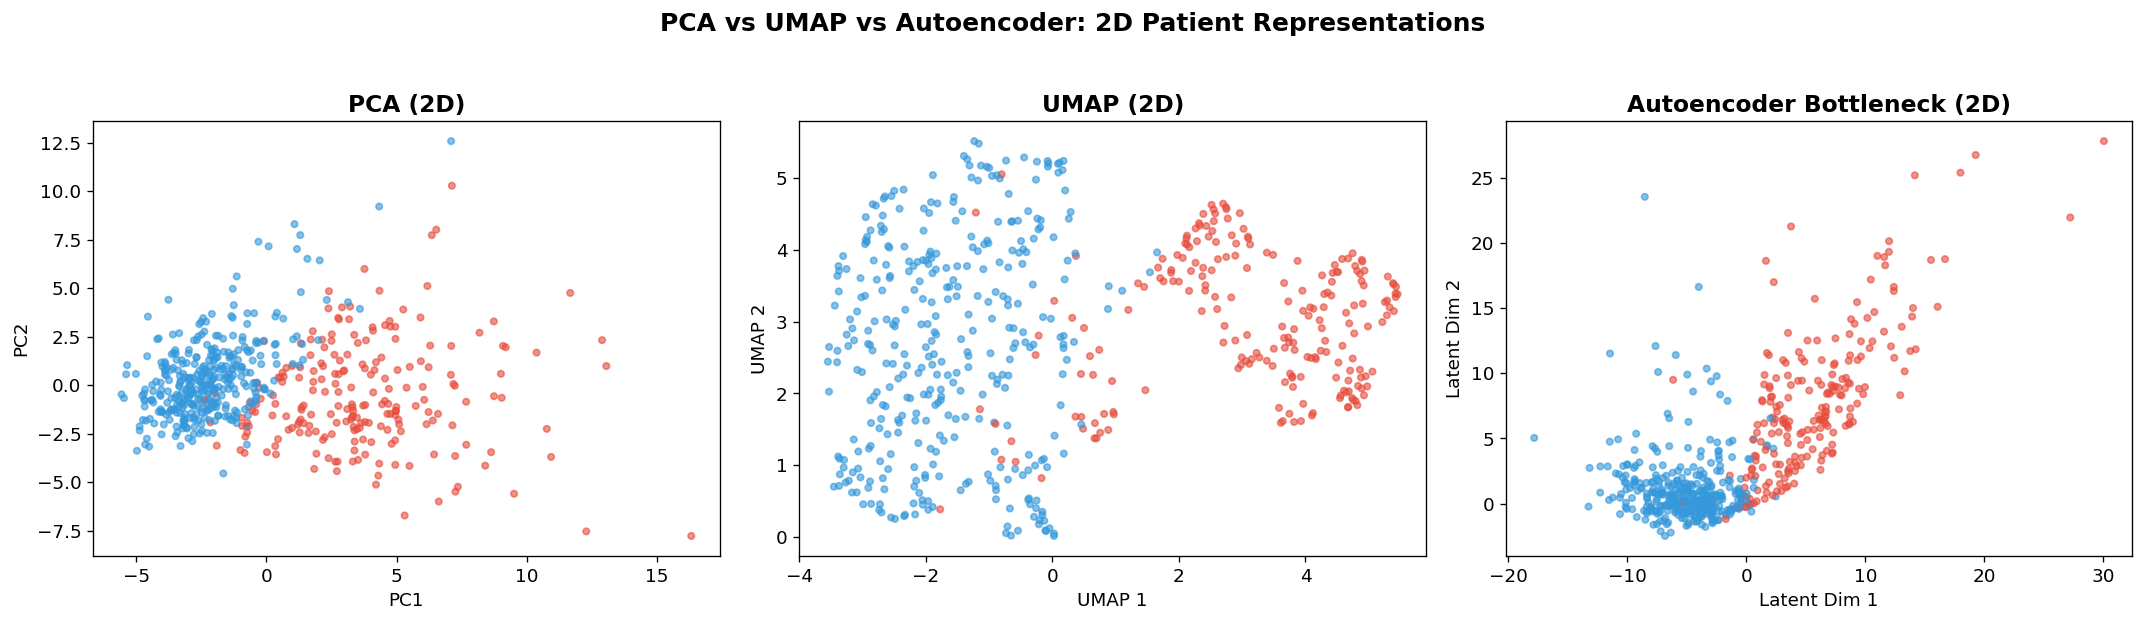

Each method produces a different 2D view of the same 30D data.
PCA: linear, preserves global variance
UMAP: non-linear, preserves local + global structure
Autoencoder: learned non-linear mapping, optimized for reconstruction

In DEC, the autoencoder is further optimized for clustering —
the bottleneck learns features that make clusters more separable.


In [94]:
# --- Visualize autoencoder bottleneck vs PCA vs UMAP ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

true_colors_vis = ['#E74C3C' if l == 0 else '#3498DB' for l in y_cancer]

# PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=true_colors_vis, alpha=0.6, s=15)
axes[0].set_title("PCA (2D)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# UMAP
axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=true_colors_vis, alpha=0.6, s=15)
axes[1].set_title("UMAP (2D)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

# Autoencoder bottleneck
if X_encoded is not None:
    axes[2].scatter(X_encoded[:, 0], X_encoded[:, 1], c=true_colors_vis, alpha=0.6, s=15)
    axes[2].set_title("Autoencoder Bottleneck (2D)", fontsize=14, fontweight='bold')
    axes[2].set_xlabel("Latent Dim 1")
    axes[2].set_ylabel("Latent Dim 2")
else:
    axes[2].text(0.5, 0.5, "Autoencoder\nnot available",
                 ha='center', va='center', fontsize=14, transform=axes[2].transAxes)
    axes[2].set_title("Autoencoder (N/A)", fontsize=14, fontweight='bold')

fig.suptitle("PCA vs UMAP vs Autoencoder: 2D Patient Representations",
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("Each method produces a different 2D view of the same 30D data.")
print("PCA: linear, preserves global variance")
print("UMAP: non-linear, preserves local + global structure")
print("Autoencoder: learned non-linear mapping, optimized for reconstruction")
print()
print("In DEC, the autoencoder is further optimized for clustering —")
print("the bottleneck learns features that make clusters more separable.")


## 11. Summary and Self-Check

### Returning to Our Patient

The 58-year-old woman who failed metformin and the 61-year-old man who
thrived on it — unsupervised learning reveals why. They likely belong to
**different diabetes subtypes** (Ahlqvist et al. found 5), each with
distinct biology, progression rates, and treatment responses.

The algorithms we practiced today — K-Means, hierarchical, DBSCAN, GMM —
are the same tools that discovered these subtypes. The visualizations —
PCA, t-SNE, UMAP — are how researchers saw the clusters for the first time.

> **The algorithm does not diagnose.** It reveals structure that was always
> there but hidden under a single label. The clinician must then validate,
> interpret, and act on that structure.

### Key Takeaways (Matching Slide S74)

1. **Unsupervised learning** discovers hidden structure without labels — essential when labels are absent, unreliable, or insufficient
2. **K-Means, DBSCAN, Hierarchical, GMM** each make different assumptions and yield different clusters — the choice depends on your clinical question
3. **Silhouette score and elbow method** guide cluster number selection — but clinical validation is the gold standard
4. **PCA (linear)** preserves global variance; **t-SNE** preserves local neighborhoods; **UMAP** preserves both local and global structure
5. **Deep clustering (DEC)** and contrastive learning capture non-linear relationships in complex medical data
6. **Clinical validation** transforms statistical clusters into actionable subtypes — clusters must predict different outcomes to matter

### Key Numbers (Matching Slide S75)

| Number | Significance |
|--------|-------------|
| 5 | Diabetes subtypes discovered from 6 variables (Ahlqvist, Lancet 2018) |
| 2.40x | Heart failure risk in ECG Cluster 1 (K-Means on CAD patients, 2025) |
| 0.645 | NMI for deep embedded clustering on medical images (CDEC) |
| 30.6% | Accuracy gain from SimCLR self-supervised pretraining over supervised baseline |
| O(n^2) | Computational complexity of t-SNE vs near-linear for UMAP |
| -1 to +1 | Silhouette score range: +1 = well-separated, 0 = overlapping, -1 = misassigned |

### Self-Check Checklist

- [ ] I can explain when unsupervised learning is needed vs supervised learning
- [ ] I implemented K-Means and used the elbow method and silhouette score to choose K
- [ ] I understand the dendrogram and how cutting at different heights gives different K
- [ ] I applied DBSCAN and can explain why it labels some patients as noise
- [ ] I used GMM and understand the difference between hard and soft assignment
- [ ] I compared PCA, t-SNE, and UMAP — and understand what each preserves and distorts
- [ ] I can interpret silhouette scores and Adjusted Rand Index for evaluating clusters
- [ ] I understand that clustering is discovery — clinical validation is what makes it useful

### Next Week Preview

**Week 12: Object Detection — YOLO for Real-Time Polyp Detection**
- This week: UNSUPERVISED discovery (what groups exist in the data?)
- Next week: SUPERVISED detection (where is this specific object?)
- Clinical scenario: Colonoscopy polyp miss rate is 22-28%. Can YOLO detect
  polyps in real-time video — like autonomous driving's pedestrian detection
  applied to the GI tract?
- Prepare: Review CNN architecture (Week 8), bounding boxes


In [95]:
# ============================================================
# Final Verification
# ============================================================
print("=" * 65)
print("Congratulations! You have completed the Week 11 Notebook!")
print("Unsupervised Learning: Clustering and Dimensionality Reduction")
print("=" * 65)

print()
print("Clustering Methods Explored:")
print("  1. K-Means: elbow plot, silhouette scores, centroid visualization")
print("  2. Hierarchical: dendrogram, Ward linkage, agglomerative clustering")
print("  3. DBSCAN: density-based clusters, noise detection, epsilon tuning")
print("  4. GMM: soft assignment, probability-based clustering, BIC/AIC")

print()
print("Dimensionality Reduction Methods:")
print("  5. PCA: linear projection, explained variance, scree plot")
print("  6. t-SNE: non-linear, local structure preservation")
print("  7. UMAP: non-linear, local + global structure, fastest")
print("  8. Autoencoder: learned non-linear mapping (bonus)")

print()
print("Visualizations Produced:")
print("  1. Feature distribution pairplots")
print("  2. Before/after scaling boxplots")
print("  3. Elbow plot and silhouette score plot")
print("  4. K-Means clusters on PCA projection")
print("  5. Hierarchical dendrogram")
print("  6. DBSCAN clusters with noise points")
print("  7. GMM hard vs soft assignment")
print("  8. PCA vs t-SNE vs UMAP triple comparison (x2)")
print("  9. PCA explained variance (scree + cumulative)")
print("  10. GMM confidence map")
print("  11. UMAP n_neighbors parameter comparison")
print("  12. PCA vs UMAP vs Autoencoder comparison")

print()
print("Returning to the diabetes subtyping mystery:")
print("  The 58-year-old woman who failed metformin and the")
print("  61-year-old man who responded -- unsupervised learning")
print("  reveals they likely belong to DIFFERENT subtypes.")
print("  Same label (Type 2), different biology, different treatment.")
print()
print("  Clustering does not diagnose. It reveals structure.")
print("  The clinician validates, interprets, and acts.")
print()
print("  Next week: From finding GROUPS to finding OBJECTS.")
print("  YOLO detects polyps in colonoscopy video -- real-time,")
print("  every frame, reducing the 22-28% miss rate to under 7%.")


Congratulations! You have completed the Week 11 Notebook!
Unsupervised Learning: Clustering and Dimensionality Reduction

Clustering Methods Explored:
  1. K-Means: elbow plot, silhouette scores, centroid visualization
  2. Hierarchical: dendrogram, Ward linkage, agglomerative clustering
  3. DBSCAN: density-based clusters, noise detection, epsilon tuning
  4. GMM: soft assignment, probability-based clustering, BIC/AIC

Dimensionality Reduction Methods:
  5. PCA: linear projection, explained variance, scree plot
  6. t-SNE: non-linear, local structure preservation
  7. UMAP: non-linear, local + global structure, fastest
  8. Autoencoder: learned non-linear mapping (bonus)

Visualizations Produced:
  1. Feature distribution pairplots
  2. Before/after scaling boxplots
  3. Elbow plot and silhouette score plot
  4. K-Means clusters on PCA projection
  5. Hierarchical dendrogram
  6. DBSCAN clusters with noise points
  7. GMM hard vs soft assignment
  8. PCA vs t-SNE vs UMAP triple compar